In [1]:
import pandas as pd
import torch
import os
from transformers import BertTokenizer


# Dataset reading

In [2]:

# Charger les fichiers CSV
file_d1 = "./kaggle/input/dataset-efw-1/D1_efw_dataset.csv"
file_d2 = "./kaggle/input/dataset-efw-1/D2_efw_dataset.csv"

df_d1 = pd.read_csv(file_d1, sep=",")  # Adapter le séparateur si nécessaire
df_d2 = pd.read_csv(file_d2, sep=",")



In [3]:
df_d1.head()

,patterns,Supp X,Supp Y,Supp Z
0,( 1+3+),1.00,0.660,0.706
1,( 3+ )( 0+3+ ),0.66,0.666,0.696
2,( 3+ )( 1+3+ ),0.66,0.541,0.692
3,( 1+ )( 3+ )( 0+3+ ),0.66,0.650,0.695
4,( 1+ )( 3+ )( 1+3+ ),0.66,0.536,0.691


In [4]:
# Définition du répertoire contenant les fichiers CSV
repertoire_donnees = "./kaggle/input/stmf-dataset/"

# Liste pour stocker les noms de fichiers et les DataFrames
noms_fichiers = []
dataframes = []

# Parcours du répertoire et chargement des fichiers CSV
for fichier in sorted(os.listdir(repertoire_donnees)):  # Tri pour garantir l'ordre
    if fichier.endswith(".csv"):  # Vérifie si c'est un fichier CSV
        chemin_fichier = os.path.join(repertoire_donnees, fichier)
        df = pd.read_csv(chemin_fichier, sep=",")  # Charger le fichier en DataFrame
        
        # Ajouter à la liste
        noms_fichiers.append(fichier)
        dataframes.append(df)

# Affichage des résultats
print("📂 Fichiers chargés :", noms_fichiers)
print(f"📊 Nombre de DataFrames chargés : {len(dataframes)}")

📂 Fichiers chargés : ['resultats_AUS.csv', 'resultats_AUT.csv', 'resultats_BEL.csv', 'resultats_BGR.csv', 'resultats_CAN.csv', 'resultats_CHE.csv', 'resultats_CHL.csv', 'resultats_CZE.csv', 'resultats_DNK.csv', 'resultats_EST.csv', 'resultats_FIN.csv', 'resultats_FRATNP.csv', 'resultats_GBRTENW.csv', 'resultats_GBR_NIR.csv', 'resultats_GBR_SCO.csv', 'resultats_GRC.csv', 'resultats_HRV.csv', 'resultats_HUN.csv', 'resultats_ISL.csv', 'resultats_ISR.csv', 'resultats_KOR.csv', 'resultats_LTU.csv', 'resultats_LUX.csv', 'resultats_LVA.csv', 'resultats_NOR.csv', 'resultats_POL.csv', 'resultats_PRT.csv']
📊 Nombre de DataFrames chargés : 27


In [5]:

# Exemple d'accès : Premier fichier et son DataFrame
if dataframes:
    print("\n🔹 Premier fichier chargé :", noms_fichiers[0])
    print(dataframes[0].head())  # Afficher les 5 premières lignes



🔹 Premier fichier chargé : resultats_AUS.csv
                                         patterns  Supp X  Supp Y  Supp Z
0                            (1+4+6+8+)(2+3+7+8+)     0.4    0.07    0.66
1            (1+4-)(4+7+8+)(3+4+7+8+)(2+3+4+7+8+)     0.4    0.06    0.66
2                                    (1+4-)(5+8+)     0.4    0.06    0.66
3  (1+4-)(2+8+)(2+3+8+)(2+7+8+)(3+7+8+)(2+3+7+8+)     0.4    0.07    0.66
4                                    (1+4-)(4+5+)     0.4    0.05    0.66


In [6]:
# Fusionner tous les DataFrames en un seul
df_combined = pd.concat(dataframes, ignore_index=True)

# Vérification des colonnes
print("📊 Colonnes du dataset fusionné :", df_combined.columns)
print(f"📈 Nombre total de lignes après fusion : {df_combined.shape[0]}")


📊 Colonnes du dataset fusionné : Index(['patterns', 'Supp X', 'Supp Y', 'Supp Z'], dtype='object')
📈 Nombre total de lignes après fusion : 14941


In [7]:
# # Fusionner les deux datasets pour augmenter la taille
# df_combined = pd.concat([df_d1, df_d2], ignore_index=True)

# # Vérification des colonnes
# print("Colonnes du dataset :", df_combined.columns)



In [8]:
print("Colonnes disponibles dans df_combined :", df_combined.columns)


Colonnes disponibles dans df_combined : Index(['patterns', 'Supp X', 'Supp Y', 'Supp Z'], dtype='object')


In [9]:
# ---- 1️⃣ Transformation : remplacer () par | ----
df_combined["patterns_transformed"] = (
    df_combined["patterns"]
    .str.replace(r"[()]", "|", regex=True)  # Remplacement
    .str.replace(r"\|+", "|", regex=True)   # Suppression des doublons
    .str.strip("|")  # Suppression des séparateurs en début/fin de chaîne
)

In [10]:
print("Colonnes disponibles dans df_combined :", df_combined.columns)

Colonnes disponibles dans df_combined : Index(['patterns', 'Supp X', 'Supp Y', 'Supp Z', 'patterns_transformed'], dtype='object')


In [11]:
df_combined.head()

,patterns,Supp X,Supp Y,Supp Z,patterns_transformed
0,(1+4+6+8+)(2+3+7+8+),0.4,0.07,0.66,1+4+6+8+|2+3+7+8+
1,(1+4-)(4+7+8+)(3+4+7+8+)(2+3+4+7+8+),0.4,0.06,0.66,1+4-|4+7+8+|3+4+7+8+|2+3+4+7+8+
2,(1+4-)(5+8+),0.4,0.06,0.66,1+4-|5+8+
3,(1+4-)(2+8+)(2+3+8+)(2+7+8+)(3+7+8+)(2+3+7+8+),0.4,0.07,0.66,1+4-|2+8+|2+3+8+|2+7+8+|3+7+8+|2+3+7+8+
4,(1+4-)(4+5+),0.4,0.05,0.66,1+4-|4+5+


In [12]:
# Extraire les motifs uniques pour éviter que le tokenizer sépare les nombres et "+"
# Nettoyage et transformation des motifs
def clean_pattern(pattern):
    """ Nettoie les motifs en supprimant les espaces inutiles autour des séparateurs """
    return " | ".join([p.strip() for p in pattern.split("|")])  # Nettoie chaque motif séparé par |

df_combined["patterns_transformed"] = df_combined["patterns_transformed"].apply(clean_pattern)

# Extraire tous les motifs uniques pour éviter les erreurs de découpage
motifs_uniques = set()
for motif in df_combined["patterns_transformed"]:
    motifs_uniques.update(motif.split(" | "))  # Ajoute chaque motif individuel

# Initialisation du tokenizer et ajout des nouveaux tokens
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tokenizer.add_tokens(list(motifs_uniques))  # Ajouter les motifs au vocabulaire

# Fonction améliorée pour la tokenisation
def tokenize_patterns(pattern):
    """ Tokenise le motif tout en vérifiant que les tokens sont bien reconnus """
    tokenized = tokenizer(pattern, padding="max_length", truncation=True, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0].tolist())
    
    # Vérification si le motif est bien tokenisé
    print(f"🔍 Motif original : {pattern}")
   # print(f"📝 Tokens générés : {tokens}\n")
    
    return tokenized["input_ids"].squeeze(0)

# Appliquer la tokenisation avec logs
df_combined["tokenized_patterns"] = df_combined["patterns_transformed"].apply(tokenize_patterns)

# Convertir les colonnes numériques en tenseurs
gs_tensor = torch.tensor(df_combined["Supp X"].values).float()
wgs_tensor = torch.tensor(df_combined["Supp Y"].values).float()
acc_tensor = torch.tensor(df_combined["Supp Z"].values).float()

# Fusionner les embeddings des motifs et les mesures en entrée du modèle
dataset_tensors = {
    "patterns": df_combined["tokenized_patterns"].tolist(),
    "gs": gs_tensor,
    "wgs": wgs_tensor,
    "acc": acc_tensor
}

# Sauvegarder le dataset préparé
#torch.save(dataset_tensors, "./kaggle/working/dataset_transformer_input.pt")
# Créer le dossier s'il n'existe pas
save_path2 = "./kaggle/working"
os.makedirs(save_path2, exist_ok=True)

file_path2 = os.path.join(save_path2, "dataset_transformer_input.pt")

# Sauvegarde
torch.save(dataset_tensors, file_path2)

print(f"Dataset sauvegardé avec succès : {file_path2}")

# Sauvegarder le tokenizer mis à jour pour réutilisation
tokenizer.save_pretrained("tokenizer_custom")

print("✅ Dataset transformé et sauvegardé sous dataset_transformer_input.pt")
print("✅ Tokenizer personnalisé sauvegardé sous tokenizer_custom/")

🔍 Motif original : 1+4+6+8+ | 2+3+7+8+
🔍 Motif original : 1+4- | 4+7+8+ | 3+4+7+8+ | 2+3+4+7+8+
🔍 Motif original : 1+4- | 5+8+
🔍 Motif original : 1+4- | 2+8+ | 2+3+8+ | 2+7+8+ | 3+7+8+ | 2+3+7+8+
🔍 Motif original : 1+4- | 4+5+
🔍 Motif original : 1+4- | 2+4+8+ | 2+3+4+8+
🔍 Motif original : 1+4- | 5+6+7+
🔍 Motif original : 1+4- | 0+2+3+
🔍 Motif original : 0+7- | 4+7+8+ | 3+4+7+8+ | 2+3+4+7+8+
🔍 Motif original : 0+7- | 5+8+
🔍 Motif original : 0+7- | 2+8+ | 2+3+8+ | 2+7+8+ | 3+7+8+ | 2+3+7+8+
🔍 Motif original : 0+7- | 4+5+
🔍 Motif original : 0+7- | 2+4+8+ | 2+3+4+8+
🔍 Motif original : 0+7- | 0+9+
🔍 Motif original : 0+7- | 5+6+7+
🔍 Motif original : 0+7- | 0+2+3+
🔍 Motif original : 1+4+ | 4+7+8+ | 3+4+7+8+ | 2+3+4+7+8+
🔍 Motif original : 1+4+ | 5+8+
🔍 Motif original : 1+4+ | 2+8+ | 2+3+8+ | 2+7+8+ | 3+7+8+ | 2+3+7+8+
🔍 Motif original : 1+4+ | 4+5+
🔍 Motif original : 1+4+ | 2+4+8+ | 2+3+4+8+
🔍 Motif original : 1+4+ | 5+6+7+
🔍 Motif original : 1+4+ | 0+2+3+
🔍 Motif original : 3+4+6+8+
🔍 Motif 

# Explorer le dataset PyTorch

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print(tokenizer.tokenize("( 1+3+ )"))  # Vérifiez comment il coupe les tokens


['(', '1', '+', '3', '+', ')']


In [14]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Désactiver la séparation automatique des caractères spéciaux
tokenizer.add_tokens(["(1+3+)", "(3+)(0+3+)"])

print(tokenizer.tokenize("(1+3+)"))  # Vérifier le découpage


['(1+3+)']


In [15]:
import pandas as pd
from transformers import AutoTokenizer

# Exemple de données
data = {
    "patterns": [
        "(1+3+)", "(3+)(0+3+)", "(3+)(1+3+)",
        "(1+)(3+)(0+3+)", "(1+)(3+)(1+3+)",
        "(0+)(3+)(0+3+)", "(0+)(3+)(1+3+)"
    ]
}
df = pd.DataFrame(data)

# ---- 1️⃣ Transformation : remplacer () par | ----
df["patterns_transformed"] = (
    df["patterns"]
    .str.replace(r"[()]", "|", regex=True)  # Remplacement
    .str.replace(r"\|+", "|", regex=True)   # Suppression des doublons
    .str.strip("|")  # Suppression des séparateurs en début/fin de chaîne
)
# ---- 2️⃣ Tokenizer personnalisé ----
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
df["tokenized"] = df["patterns_transformed"].apply(lambda x: tokenizer.tokenize(x))

# ---- 3️⃣ Affichage des résultats ----
print("📌 Données originales")
print(df[["patterns"]])

print("\n🔹 Représentation avec | au lieu des parenthèses")
print(df[["patterns_transformed"]])

print("\n🔹 Tokenization (BERT)")
print(df[["tokenized"]])


📌 Données originales
         patterns
0          (1+3+)
1      (3+)(0+3+)
2      (3+)(1+3+)
3  (1+)(3+)(0+3+)
4  (1+)(3+)(1+3+)
5  (0+)(3+)(0+3+)
6  (0+)(3+)(1+3+)

🔹 Représentation avec | au lieu des parenthèses
  patterns_transformed
0                 1+3+
1              3+|0+3+
2              3+|1+3+
3           1+|3+|0+3+
4           1+|3+|1+3+
5           0+|3+|0+3+
6           0+|3+|1+3+

🔹 Tokenization (BERT)
                        tokenized
0                    [1, +, 3, +]
1           [3, +, |, 0, +, 3, +]
2           [3, +, |, 1, +, 3, +]
3  [1, +, |, 3, +, |, 0, +, 3, +]
4  [1, +, |, 3, +, |, 1, +, 3, +]
5  [0, +, |, 3, +, |, 0, +, 3, +]
6  [0, +, |, 3, +, |, 1, +, 3, +]


In [16]:

# Charger le dataset sauvegardé
dataset_path = "./kaggle/working/dataset_transformer_input.pt"  # Adapter le chemin si nécessaire
dataset_tensors = torch.load(dataset_path)

# Vérifier les clés du dataset
print("🔍 Clés disponibles dans le dataset :", dataset_tensors.keys())

# Afficher un aperçu des données
print("\n📝 Exemple de données tokenisées :", dataset_tensors["patterns"][:3])  # Afficher 3 exemples
print("\n📊 Valeurs GS :", dataset_tensors["gs"][:5])  # Afficher 5 premières valeurs GS
print("\n📊 Valeurs WGS :", dataset_tensors["wgs"][:5])  # Afficher 5 premières valeurs WGS
print("\n📊 Valeurs ACC :", dataset_tensors["acc"][:5])  # Afficher 5 premières valeurs ACC)


🔍 Clés disponibles dans le dataset : dict_keys(['patterns', 'gs', 'wgs', 'acc'])

📝 Exemple de données tokenisées : [tensor([  101, 30763,  1064, 30538,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,    

# Training Model

## Intégration au Modèle de Machine Learning

Maintenant que la tokenisation est corrigée et que les motifs sont bien représentés dans le vocabulaire, voici les prochaines étapes :
📌 Étapes suivantes

1️⃣ Préparer les Tenseurs pour le Modèle

    Vérifier la taille des tenseurs et s'assurer qu'ils sont compatibles avec le modèle.
    Normaliser les valeurs si nécessaire.

2️⃣ Définir le Modèle Transformer

    Charger un modèle BERT ou Transformer personnalisé.
    Adapter la couche d'entrée pour traiter les tokens des motifs + les mesures numériques (Supp X, Supp Y, Supp Z).

3️⃣ Entraînement du Modèle

    Diviser le dataset en train/test.
    Définir une fonction de loss et un optimizer.
    Lancer l'entraînement et suivre la courbe de précision / perte.

4️⃣ Évaluation et Amélioration

    Tester le modèle sur des motifs non vus.
    Analyser les erreurs et ajuster le modèle si besoin (ex: data augmentation).

5️⃣ Déploiement et Utilisation

    Sauvegarder le modèle (.pt ou .pkl).
    Créer une API Flask/FastAPI pour l’utiliser en inférence sur de nouveaux motifs.



## Étape 1 : Chargement des Données et Prétraitement

Vérifions d'abord que les données sont bien prêtes et utilisables par le modèle.
1️⃣ Charger le dataset transformé

In [17]:
#import torch

# Charger le dataset transformé
dataset_path = "./kaggle/working/dataset_transformer_input.pt"
dataset_tensors = torch.load(dataset_path)

# Vérifier les clés et formats
print("Clés disponibles :", dataset_tensors.keys())
print("Exemple de tokenized_patterns :", dataset_tensors["patterns"][0])
print("Shape des tenseurs gs, wgs, acc :", dataset_tensors["gs"].shape, dataset_tensors["wgs"].shape, dataset_tensors["acc"].shape)


Clés disponibles : dict_keys(['patterns', 'gs', 'wgs', 'acc'])
Exemple de tokenized_patterns : tensor([  101, 30763,  1064, 30538,   102,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     

## 2️⃣ Convertir les données en un DataLoader

Nous devons créer un Dataset PyTorch et un DataLoader pour charger les données efficacement.

In [18]:
# from torch.utils.data import Dataset, DataLoader
# from sklearn.preprocessing import MinMaxScaler
# import torch

# class MotifDataset(Dataset):
#     def __init__(self, dataset, normalize=True):
#         self.patterns = dataset["patterns"]
#         self.gs = dataset["gs"]
#         self.wgs = dataset["wgs"]
#         self.acc = dataset["acc"]
        
#         # Normalisation des features numériques
#         if normalize:
#             scaler = MinMaxScaler()
#             self.gs = scaler.fit_transform(self.gs.reshape(-1, 1)).flatten()
#             self.wgs = scaler.fit_transform(self.wgs.reshape(-1, 1)).flatten()
#             self.acc = scaler.fit_transform(self.acc.reshape(-1, 1)).flatten()

#     def __len__(self):
#         return len(self.gs)

#     def __getitem__(self, idx):
#         return {
#             "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),  # Séquence tokenisée long remplacer flaot 32
#             "gs": torch.tensor(self.gs[idx], dtype=torch.float32),  # Valeur normalisée de Supp X
#             "wgs": torch.tensor(self.wgs[idx], dtype=torch.float32),  # Valeur normalisée de Supp Y
#             "acc": torch.tensor(self.acc[idx], dtype=torch.float32)  # Valeur normalisée de Supp Z
#         }

# # Création du dataset avec normalisation
# motif_dataset = MotifDataset(dataset_tensors, normalize=True)

# # Création du DataLoader
# dataloader = DataLoader(motif_dataset, batch_size=16, shuffle=True)

# # Tester un batch
# for batch in dataloader:
#     print("Exemple de batch normalisé :", batch)
#     break


from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch

# ⚠️ Séparation des données en train/test AVANT de créer les datasets
patterns = dataset_tensors["patterns"]
gs = dataset_tensors["gs"]
wgs = dataset_tensors["wgs"]
acc = dataset_tensors["acc"]

patterns_train, patterns_test, gs_train, gs_test, wgs_train, wgs_test, acc_train, acc_test = train_test_split(
    patterns, gs, wgs, acc, test_size=0.2, random_state=42
)

class MotifDataset(Dataset):
    def __init__(self, dataset, normalize=True):
        self.patterns = dataset["patterns"]
        self.gs = dataset["gs"]
        self.wgs = dataset["wgs"]
        self.acc = dataset["acc"]

        # Normalisation des features numériques
        if normalize:
            scaler = MinMaxScaler()
            self.gs = scaler.fit_transform(self.gs.reshape(-1, 1)).flatten()
            self.wgs = scaler.fit_transform(self.wgs.reshape(-1, 1)).flatten()
            self.acc = scaler.fit_transform(self.acc.reshape(-1, 1)).flatten()

    def __len__(self):
        return len(self.gs)

    def __getitem__(self, idx):
        return {
            "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),
            "gs": torch.tensor(self.gs[idx], dtype=torch.float32),
            "wgs": torch.tensor(self.wgs[idx], dtype=torch.float32),
            "acc": torch.tensor(self.acc[idx], dtype=torch.float32)
        }

# Création des datasets normalisés
train_dataset = MotifDataset({
    "patterns": patterns_train,
    "gs": gs_train,
    "wgs": wgs_train,
    "acc": acc_train
}, normalize=True)

test_dataset = MotifDataset({
    "patterns": patterns_test,
    "gs": gs_test,
    "wgs": wgs_test,
    "acc": acc_test
}, normalize=True)

# Création des DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Vérification d’un batch
for batch in train_loader:
    print("✅ Exemple de batch normalisé :", batch)
    break


✅ Exemple de batch normalisé : {'patterns': tensor([[  101, 30864,  1064,  ...,     0,     0,     0],
        [  101, 30705,  1064,  ...,     0,     0,     0],
        [  101, 30543,  1064,  ...,     0,     0,     0],
        ...,
        [  101, 30635,  1064,  ...,     0,     0,     0],
        [  101, 30522,  1064,  ...,     0,     0,     0],
        [  101, 30908,  1064,  ...,     0,     0,     0]]), 'gs': tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0667, 0.0000, 0.0667, 0.0000,
        0.0000, 0.0000, 0.1667, 0.1667, 0.0000, 0.0000, 0.0000]), 'wgs': tensor([0.0000, 0.0000, 0.0000, 0.0244, 0.0000, 0.0244, 0.0244, 0.4634, 0.1463,
        0.0000, 0.0000, 0.0244, 0.1220, 0.0244, 0.0976, 0.0488]), 'acc': tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.2500, 0.2500,
        0.0000, 0.0000, 0.2500, 0.2500, 0.0000, 0.2500, 0.0000])}


/tmp/ipykernel_18828/3372165585.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),


In [19]:
!pip install seaborn

/tmp/ipykernel_18828/3372165585.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),


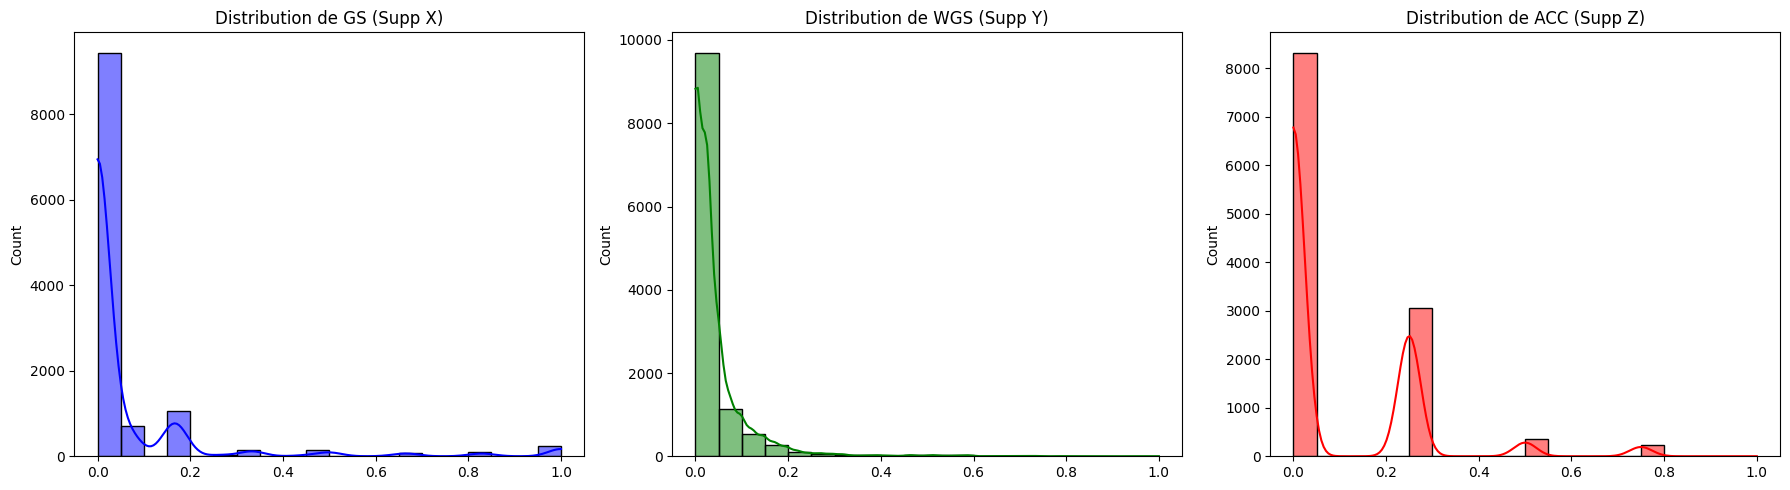

In [20]:
# visualiser donnees train 
import matplotlib.pyplot as plt
import seaborn as sns

# Extraction des données sous forme de liste depuis le train_dataset
all_gs = [x["gs"].item() for x in train_dataset]
all_wgs = [x["wgs"].item() for x in train_dataset]
all_acc = [x["acc"].item() for x in train_dataset]


# Création des subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramme de gs (Supp X)
sns.histplot(all_gs, bins=20, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Distribution de GS (Supp X)")

# Histogramme de wgs (Supp Y)
sns.histplot(all_wgs, bins=20, kde=True, ax=axes[1], color="green")
axes[1].set_title("Distribution de WGS (Supp Y)")

# Histogramme de acc (Supp Z)
sns.histplot(all_acc, bins=20, kde=True, ax=axes[2], color="red")
axes[2].set_title("Distribution de ACC (Supp Z)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_18828/3372165585.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),


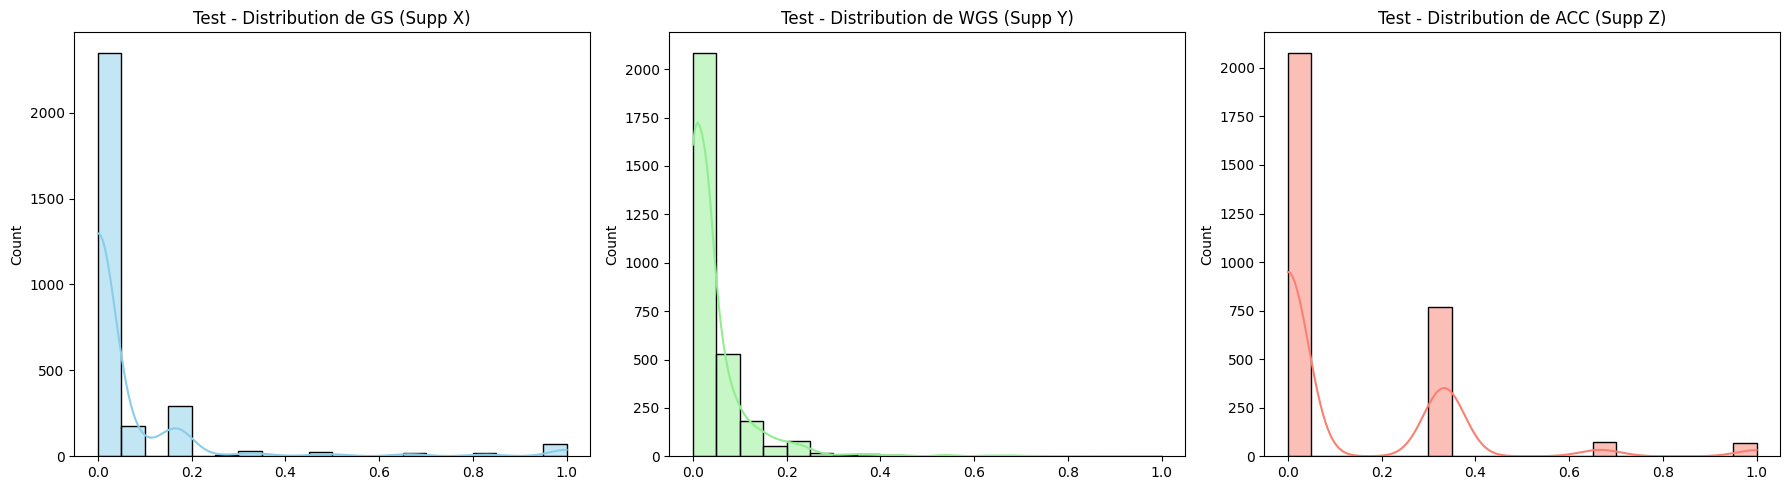

In [21]:
# visualiser donnees test
import matplotlib.pyplot as plt
import seaborn as sns

# Extraction des données depuis test_dataset
test_gs = [x["gs"].item() for x in test_dataset]
test_wgs = [x["wgs"].item() for x in test_dataset]
test_acc = [x["acc"].item() for x in test_dataset]

# Création des subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramme de gs (Supp X)
sns.histplot(test_gs, bins=20, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Test - Distribution de GS (Supp X)")

# Histogramme de wgs (Supp Y)
sns.histplot(test_wgs, bins=20, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Test - Distribution de WGS (Supp Y)")

# Histogramme de acc (Supp Z)
sns.histplot(test_acc, bins=20, kde=True, ax=axes[2], color="salmon")
axes[2].set_title("Test - Distribution de ACC (Supp Z)")

plt.tight_layout()
plt.show()




## 🔍 Visualisation comparative : Train vs Test

/tmp/ipykernel_18828/3372165585.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),


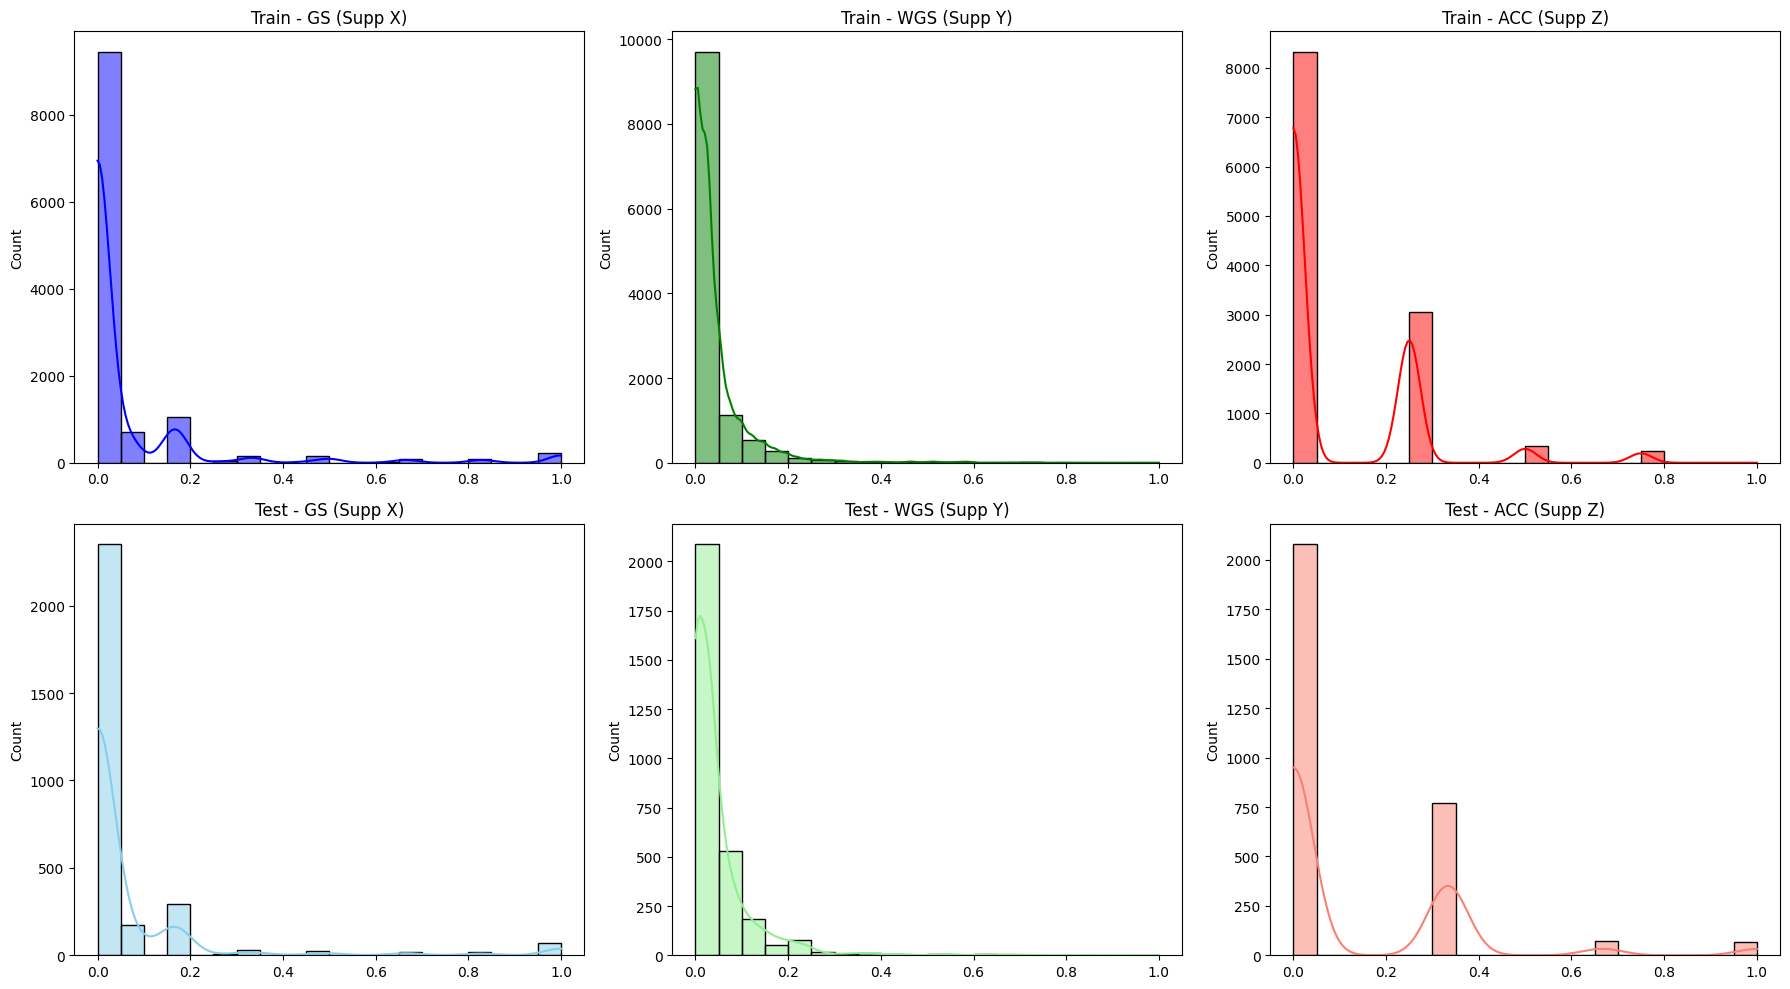

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train dataset ---
train_gs = [x["gs"].item() for x in train_dataset]
train_wgs = [x["wgs"].item() for x in train_dataset]
train_acc = [x["acc"].item() for x in train_dataset]

# --- Test dataset ---
test_gs = [x["gs"].item() for x in test_dataset]
test_wgs = [x["wgs"].item() for x in test_dataset]
test_acc = [x["acc"].item() for x in test_dataset]

# --- Création des subplots 2 lignes x 3 colonnes ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Ligne 1 : Train
sns.histplot(train_gs, bins=20, kde=True, ax=axes[0, 0], color="blue")
axes[0, 0].set_title("Train - GS (Supp X)")

sns.histplot(train_wgs, bins=20, kde=True, ax=axes[0, 1], color="green")
axes[0, 1].set_title("Train - WGS (Supp Y)")

sns.histplot(train_acc, bins=20, kde=True, ax=axes[0, 2], color="red")
axes[0, 2].set_title("Train - ACC (Supp Z)")

# Ligne 2 : Test
sns.histplot(test_gs, bins=20, kde=True, ax=axes[1, 0], color="skyblue")
axes[1, 0].set_title("Test - GS (Supp X)")

sns.histplot(test_wgs, bins=20, kde=True, ax=axes[1, 1], color="lightgreen")
axes[1, 1].set_title("Test - WGS (Supp Y)")

sns.histplot(test_acc, bins=20, kde=True, ax=axes[1, 2], color="salmon")
axes[1, 2].set_title("Test - ACC (Supp Z)")

plt.tight_layout()
plt.show()


## 📊 Statistiques descriptives des jeux de données

In [23]:
import pandas as pd

# Extraire les valeurs depuis les datasets
train_data = {
    "gs": [x["gs"].item() for x in train_dataset],
    "wgs": [x["wgs"].item() for x in train_dataset],
    "acc": [x["acc"].item() for x in train_dataset]
}

test_data = {
    "gs": [x["gs"].item() for x in test_dataset],
    "wgs": [x["wgs"].item() for x in test_dataset],
    "acc": [x["acc"].item() for x in test_dataset]
}

# Convertir en DataFrames pour résumé statistique
df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

# Calcul des statistiques
print("📘 Statistiques du TRAIN dataset :")
print(df_train.describe().T[["min", "mean", "50%", "max", "std"]].rename(columns={"50%": "median"}))

print("\n📙 Statistiques du TEST dataset :")
print(df_test.describe().T[["min", "mean", "50%", "max", "std"]].rename(columns={"50%": "median"}))


/tmp/ipykernel_18828/3372165585.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),


📘 Statistiques du TRAIN dataset :
     min      mean   median  max       std
gs   0.0  0.060604  0.00000  1.0  0.178013
wgs  0.0  0.041103  0.02439  1.0  0.072006
acc  0.0  0.093060  0.00000  1.0  0.160192

📙 Statistiques du TEST dataset :
     min      mean    median  max       std
gs   0.0  0.061158  0.000000  1.0  0.181471
wgs  0.0  0.047694  0.029412  1.0  0.081769
acc  0.0  0.124902  0.000000  1.0  0.216314


/tmp/ipykernel_18828/3372165585.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),


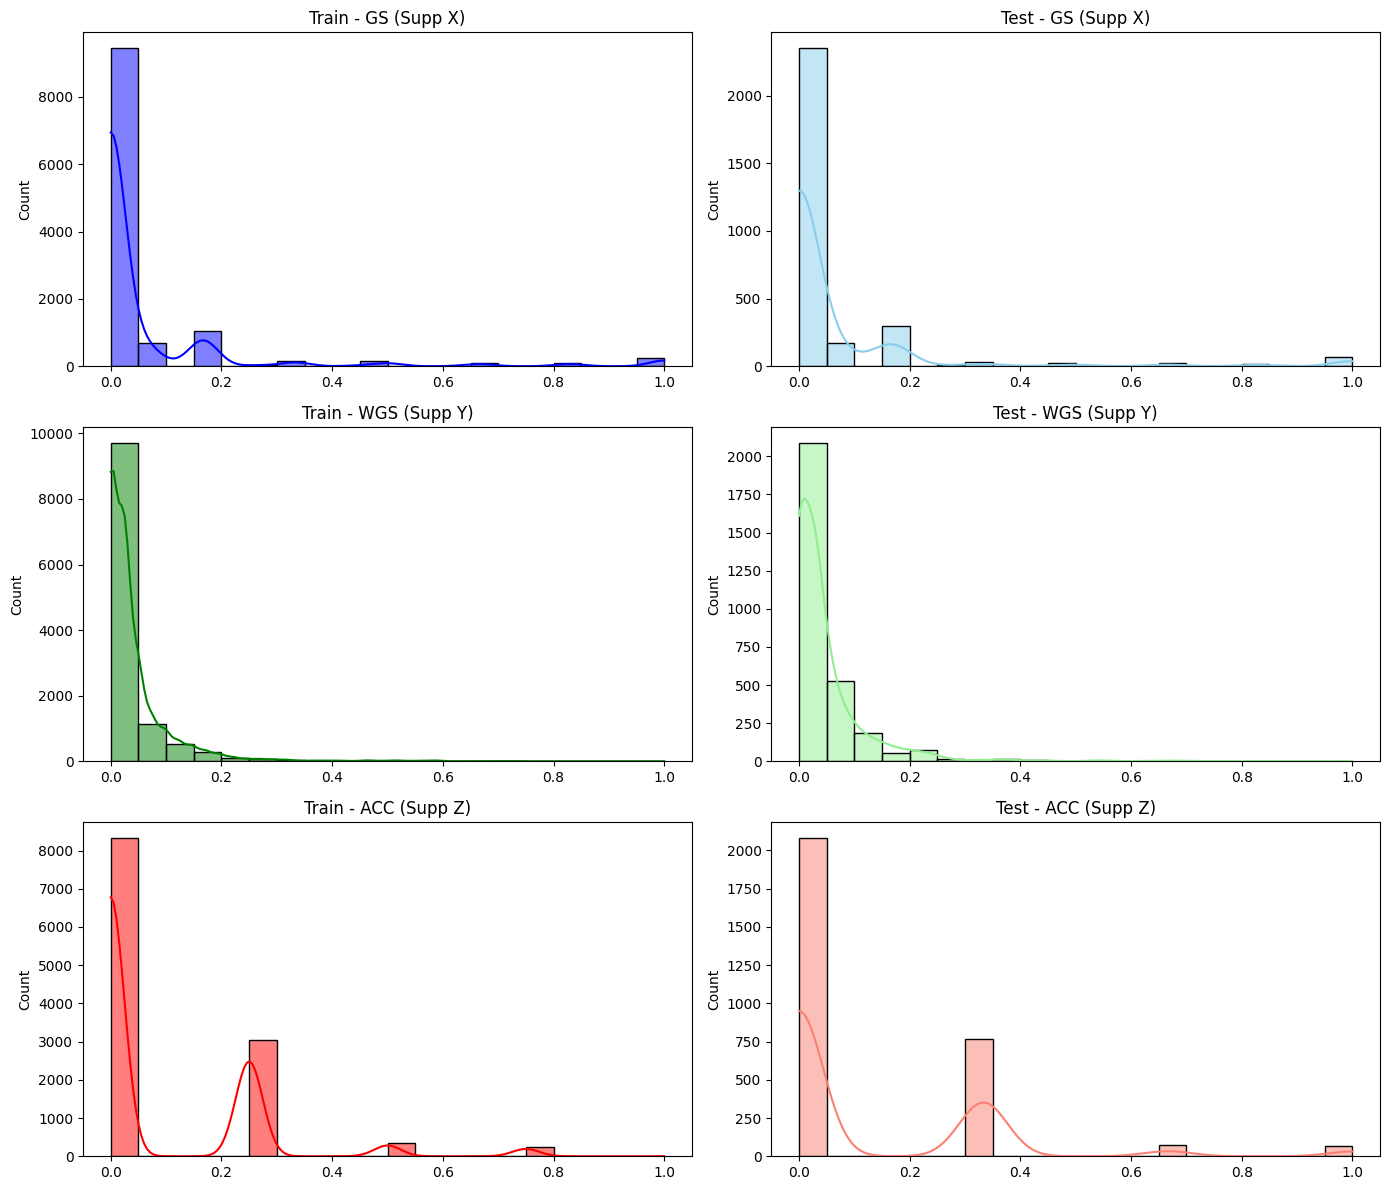

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def extract_values(dataset):
    gs = [x["gs"].item() for x in dataset]
    wgs = [x["wgs"].item() for x in dataset]
    acc = [x["acc"].item() for x in dataset]
    return gs, wgs, acc

# Extraire les données des deux jeux
train_gs, train_wgs, train_acc = extract_values(train_dataset)
test_gs, test_wgs, test_acc = extract_values(test_dataset)

# Préparer les subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# GS
sns.histplot(train_gs, bins=20, kde=True, ax=axes[0, 0], color="blue", label="Train")
axes[0, 0].set_title("Train - GS (Supp X)")
sns.histplot(test_gs, bins=20, kde=True, ax=axes[0, 1], color="skyblue", label="Test")
axes[0, 1].set_title("Test - GS (Supp X)")

# WGS
sns.histplot(train_wgs, bins=20, kde=True, ax=axes[1, 0], color="green")
axes[1, 0].set_title("Train - WGS (Supp Y)")
sns.histplot(test_wgs, bins=20, kde=True, ax=axes[1, 1], color="lightgreen")
axes[1, 1].set_title("Test - WGS (Supp Y)")

# ACC
sns.histplot(train_acc, bins=20, kde=True, ax=axes[2, 0], color="red")
axes[2, 0].set_title("Train - ACC (Supp Z)")
sns.histplot(test_acc, bins=20, kde=True, ax=axes[2, 1], color="salmon")
axes[2, 1].set_title("Test - ACC (Supp Z)")

plt.tight_layout()
plt.show()


## ✅ Code : détection des outliers pour train et test sur trois variables

In [25]:
import numpy as np

def detect_outliers(data):
    """ Détection des valeurs aberrantes avec la méthode de l'IQR """
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return [x for x in data if x < lower_bound or x > upper_bound]

# --- Extraction des valeurs
train_gs = [x["gs"].item() for x in train_dataset]
train_wgs = [x["wgs"].item() for x in train_dataset]
train_acc = [x["acc"].item() for x in train_dataset]

test_gs = [x["gs"].item() for x in test_dataset]
test_wgs = [x["wgs"].item() for x in test_dataset]
test_acc = [x["acc"].item() for x in test_dataset]

# --- Détection des outliers
out_train_gs = detect_outliers(train_gs)
out_train_wgs = detect_outliers(train_wgs)
out_train_acc = detect_outliers(train_acc)

out_test_gs = detect_outliers(test_gs)
out_test_wgs = detect_outliers(test_wgs)
out_test_acc = detect_outliers(test_acc)

# --- Affichage des résultats
print("📊 Outliers détectés dans TRAIN dataset :")
print(f"   ➤ GS  : {len(out_train_gs)} / {len(train_gs)} ({len(out_train_gs)/len(train_gs)*100:.2f}%)")
print(f"   ➤ WGS : {len(out_train_wgs)} / {len(train_wgs)} ({len(out_train_wgs)/len(train_wgs)*100:.2f}%)")
print(f"   ➤ ACC : {len(out_train_acc)} / {len(train_acc)} ({len(out_train_acc)/len(train_acc)*100:.2f}%)")

print("\n📊 Outliers détectés dans TEST dataset :")
print(f"   ➤ GS  : {len(out_test_gs)} / {len(test_gs)} ({len(out_test_gs)/len(test_gs)*100:.2f}%)")
print(f"   ➤ WGS : {len(out_test_wgs)} / {len(test_wgs)} ({len(out_test_wgs)/len(test_wgs)*100:.2f}%)")
print(f"   ➤ ACC : {len(out_test_acc)} / {len(test_acc)} ({len(out_test_acc)/len(test_acc)*100:.2f}%)")


/tmp/ipykernel_18828/3372165585.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),


📊 Outliers détectés dans TRAIN dataset :
   ➤ GS  : 2506 / 11952 (20.97%)
   ➤ WGS : 1125 / 11952 (9.41%)
   ➤ ACC : 236 / 11952 (1.97%)

📊 Outliers détectés dans TEST dataset :
   ➤ GS  : 639 / 2989 (21.38%)
   ➤ WGS : 270 / 2989 (9.03%)
   ➤ ACC : 69 / 2989 (2.31%)


In [26]:
def replace_outliers(data):
    """Remplace les outliers par la médiane"""
    median = np.median(data)
    Q1, Q3 = np.percentile(data, [25, 75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return [x if lower_bound <= x <= upper_bound else median for x in data]


In [27]:
# Train
train_gs = [x["gs"].item() for x in train_dataset]
train_wgs = [x["wgs"].item() for x in train_dataset]
train_acc = [x["acc"].item() for x in train_dataset]

# Test
test_gs = [x["gs"].item() for x in test_dataset]
test_wgs = [x["wgs"].item() for x in test_dataset]
test_acc = [x["acc"].item() for x in test_dataset]



/tmp/ipykernel_18828/3372165585.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "patterns": torch.tensor(self.patterns[idx], dtype=torch.long),


In [28]:
# Train cleaned
clean_train_gs = replace_outliers(train_gs)
clean_train_wgs = replace_outliers(train_wgs)
clean_train_acc = replace_outliers(train_acc)

# Test cleaned
clean_test_gs = replace_outliers(test_gs)
clean_test_wgs = replace_outliers(test_wgs)
clean_test_acc = replace_outliers(test_acc)


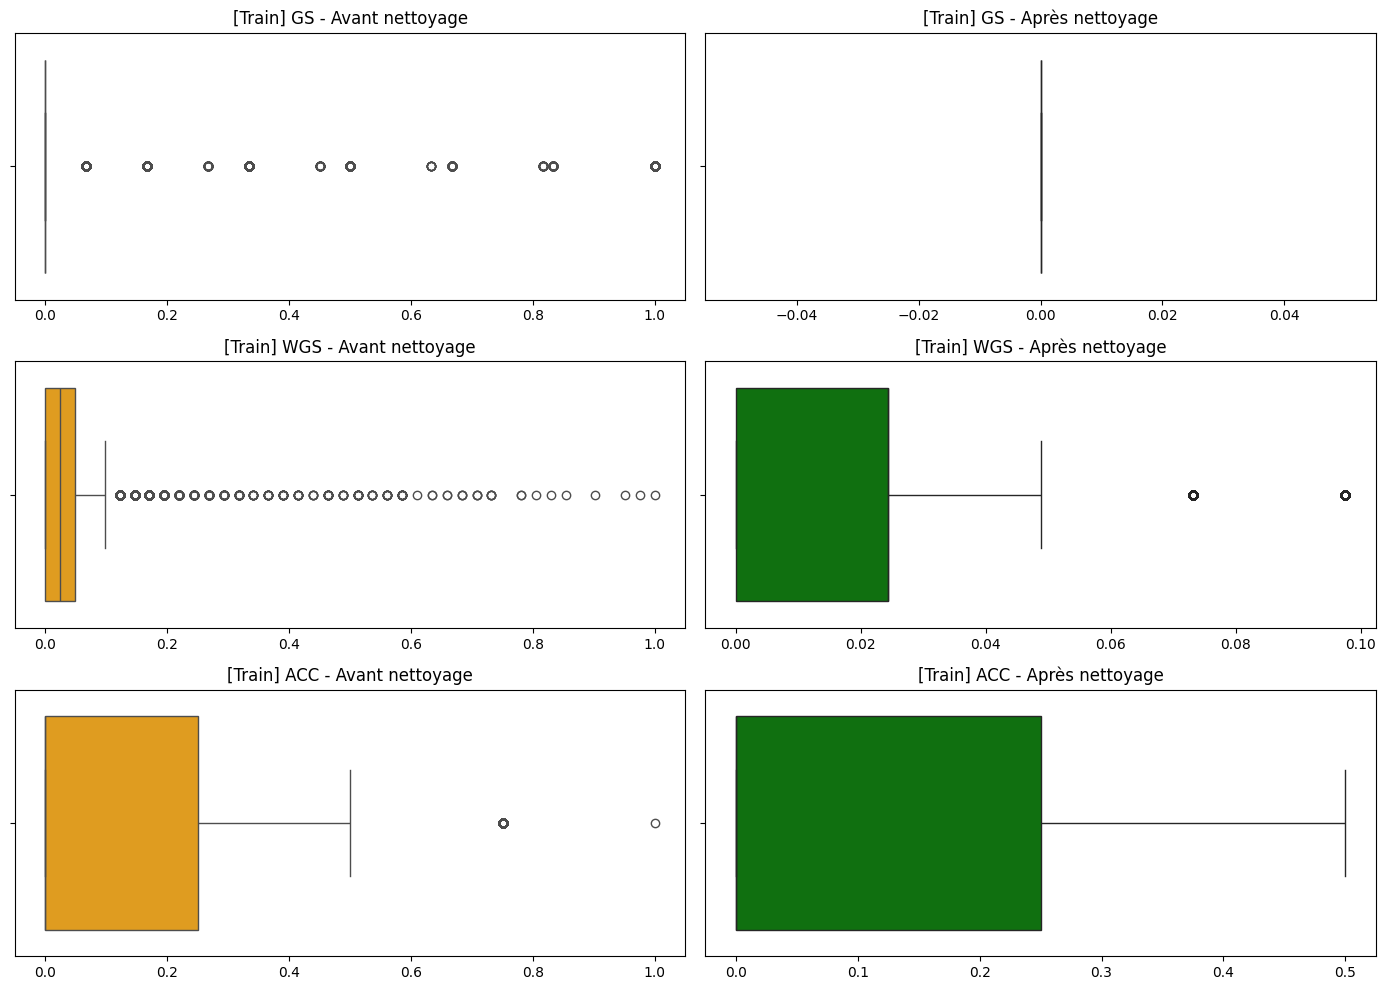

In [29]:
# Créer la figure train
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
variables = [("gs", train_gs, clean_train_gs),
             ("wgs", train_wgs, clean_train_wgs),
             ("acc", train_acc, clean_train_acc)]

for i, (name, original, cleaned) in enumerate(variables):
    sns.boxplot(x=original, ax=axes[i][0], color="orange")
    axes[i][0].set_title(f"[Train] {name.upper()} - Avant nettoyage")
    
    sns.boxplot(x=cleaned, ax=axes[i][1], color="green")
    axes[i][1].set_title(f"[Train] {name.upper()} - Après nettoyage")

plt.tight_layout()
plt.show()


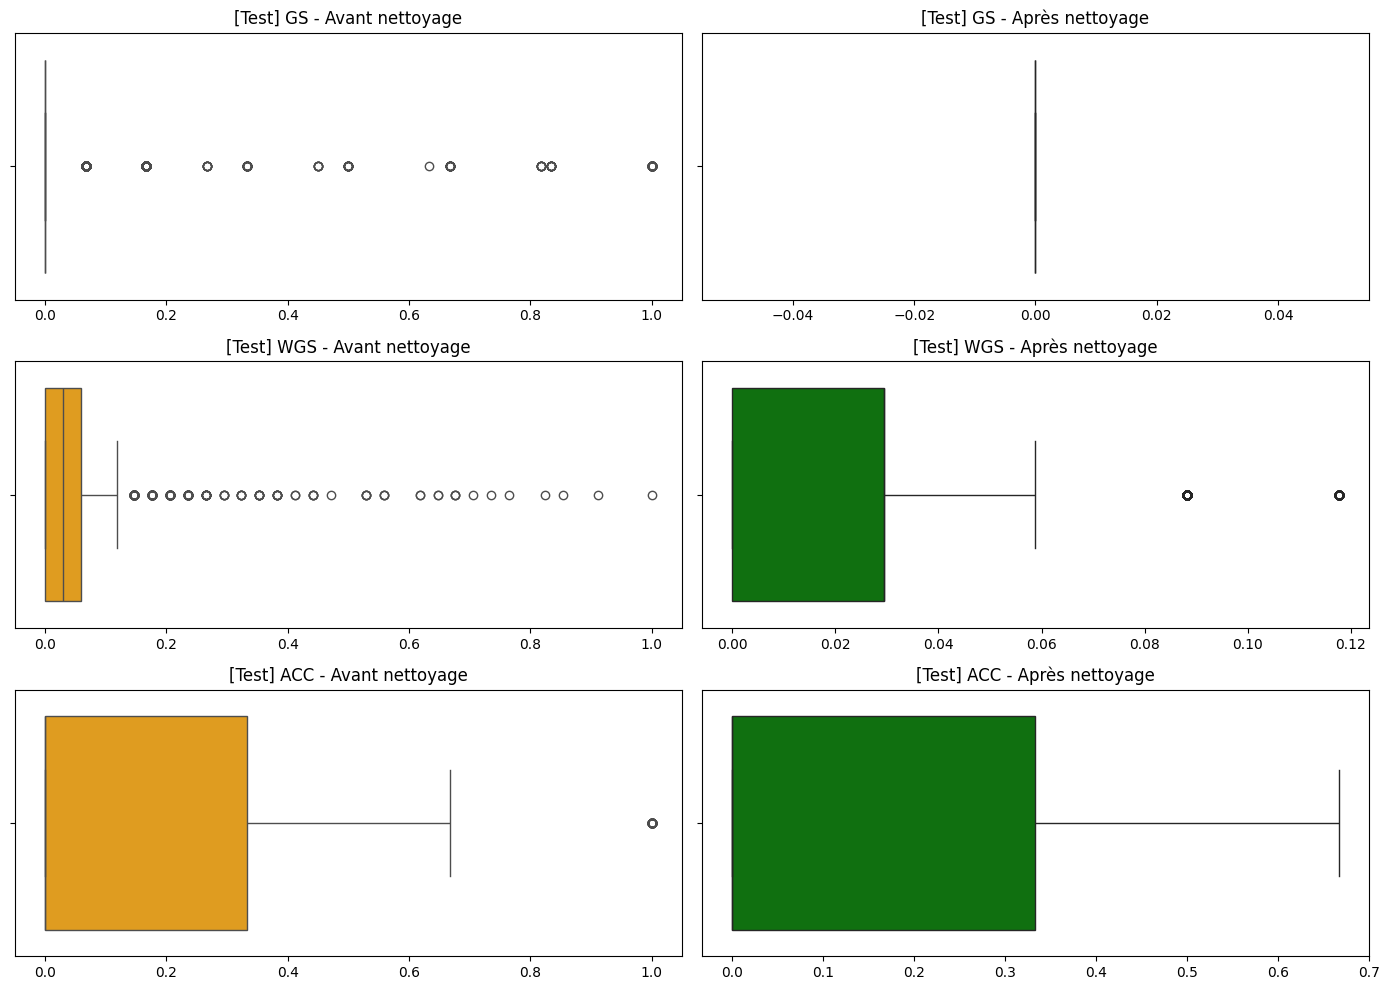

In [30]:
# Créer la figure pour test dataset
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
variables = [("gs", test_gs, clean_test_gs),
             ("wgs", test_wgs, clean_test_wgs),
             ("acc", test_acc, clean_test_acc)]

for i, (name, original, cleaned) in enumerate(variables):
    sns.boxplot(x=original, ax=axes[i][0], color="orange")
    axes[i][0].set_title(f"[Test] {name.upper()} - Avant nettoyage")
    
    sns.boxplot(x=cleaned, ax=axes[i][1], color="green")
    axes[i][1].set_title(f"[Test] {name.upper()} - Après nettoyage")

plt.tight_layout()
plt.show()


In [31]:
# filtered_gs = [x for x in all_gs if x not in outliers_gs]
# filtered_wgs = [x for x in all_wgs if x not in outliers_wgs]
# filtered_acc = [x for x in all_acc if x not in outliers_acc]



## Étape 2 : Définition du Modèle Transformer

Nous allons créer un modèle utilisant une couche Transformer Encoder pour traiter les motifs et les fusionner avec les valeurs numériques.

### 1️⃣ Définir l'architecture
✅ Objectif : Construire un modèle Transformer qui prend en entrée les tokens des motifs + les valeurs numériques.

In [32]:
import torch
import torch.nn as nn

class TransformerRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=6, ff_dim=256, output_dim=3):
        super(TransformerRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=ff_dim
        )
        self.transformer_encoder = nn.TransformerEncoder(
            self.encoder_layer, 
            num_layers=num_layers
        )

        # Couche pour fusionner les valeurs numériques d'entrée
        self.fc_numeric = nn.Linear(3, embed_dim)  # Entrée: GS, WGS, ACC

        # Couche de sortie → 3 sorties : GS, WGS, ACC
        self.fc_out = nn.Linear(embed_dim, output_dim)

    def forward(self, patterns, gs, wgs, acc):
        embedded_patterns = self.embedding(patterns)  # [batch, seq_len, embed_dim]
        transformer_output = self.transformer_encoder(embedded_patterns)  # [batch, seq_len, embed_dim]

        # Utiliser le premier token ([CLS] position)
        cls_token = transformer_output[:, 0, :]  # [batch, embed_dim]

        # Traitement des features numériques
        numeric_input = torch.cat([gs.unsqueeze(1), wgs.unsqueeze(1), acc.unsqueeze(1)], dim=1)  # [batch, 3]
        numeric_embedding = self.fc_numeric(numeric_input)  # [batch, embed_dim]

        # Fusion des embeddings
        combined = cls_token + numeric_embedding  # [batch, embed_dim]

        # Prédiction multi-sortie
        return self.fc_out(combined)  # [batch, 3]

# Exemple d’instanciation
vocab_size = 30990
model = TransformerRegressor(vocab_size)

# Déplacement sur GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)


TransformerRegressor(
  (embedding): Embedding(30990, 128)
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (linear1): Linear(in_features=128, out_features=256, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=256, out_features=128, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dr

/tmp/ipykernel_18828/3392345524.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(
/home/fotso/Documents/gitlab/UPDATED/SequuentialGradualPatternApproch/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 📌 Étape 3 : Entraînement du Modèle

Using device: cpu
Dataset size: 14941
Train size: 10458
Test size: 4483

Training variant: Full model
Epoch [01/15] | Loss: 0.006831
Epoch [02/15] | Loss: 0.001767
Epoch [03/15] | Loss: 0.001111
Epoch [04/15] | Loss: 0.000822
Epoch [05/15] | Loss: 0.000647
Epoch [06/15] | Loss: 0.000498
Epoch [07/15] | Loss: 0.000405
Epoch [08/15] | Loss: 0.000369
Epoch [09/15] | Loss: 0.000324
Epoch [10/15] | Loss: 0.000284
Epoch [11/15] | Loss: 0.000278
Epoch [12/15] | Loss: 0.000246
Epoch [13/15] | Loss: 0.000252
Epoch [14/15] | Loss: 0.000206
Epoch [15/15] | Loss: 0.000202
Completed: Full model
Training time: 10085.80 seconds
Memory variation: 641.84 MB
Convergence epoch: 14

Training variant: Without WGS
Epoch [01/15] | Loss: 0.004574
Epoch [02/15] | Loss: 0.001543
Epoch [03/15] | Loss: 0.001190
Epoch [04/15] | Loss: 0.001031
Epoch [05/15] | Loss: 0.000939
Epoch [06/15] | Loss: 0.000830
Epoch [07/15] | Loss: 0.000792
Epoch [08/15] | Loss: 0.000729
Epoch [09/15] | Loss: 0.000666
Epoch [10/15] | Los

,Model Variant,MAE,RMSE,Pearson,Training Time (s),Memory Usage (MB),Convergence Epoch
0,Full model,0.006168,0.007921,0.998165,10085.801511,641.843750,14
1,Without WGS,0.012647,0.026083,0.943757,9371.430647,130.605469,15
2,Without ACC,0.018569,0.029897,0.985184,9718.580912,-242.312500,14
3,Without numerical features,0.048890,0.089618,0.686756,9925.661246,-75.585938,14
4,Without Transformer,0.003562,0.004773,0.999717,12.345369,0.589844,13



Ablation study results saved.


,Comparison,t-statistic,p-value,Significant (p < 0.05)
0,Full model vs Without WGS,-33.924812,9.545402e-225,True
1,Full model vs Without ACC,-86.778793,0.000000e+00,True
2,Full model vs Without numerical features,-50.547137,0.000000e+00,True
3,Full model vs Without Transformer,44.624876,0.000000e+00,True


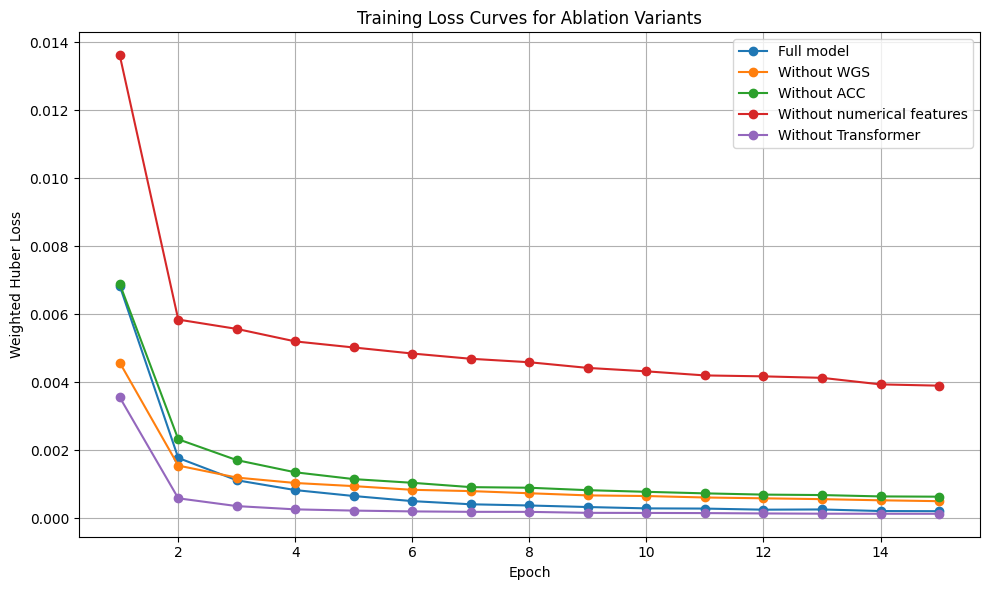

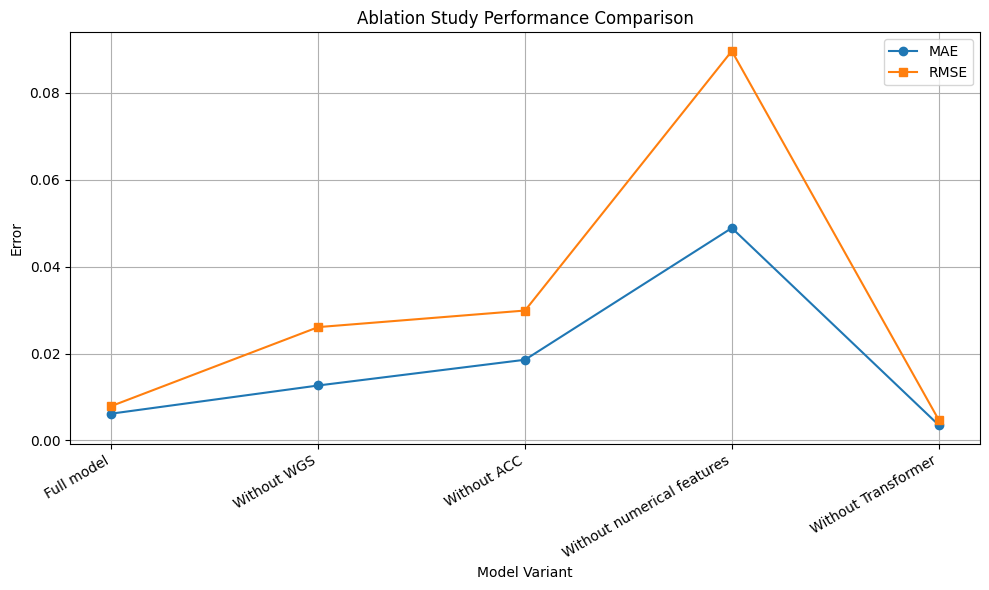

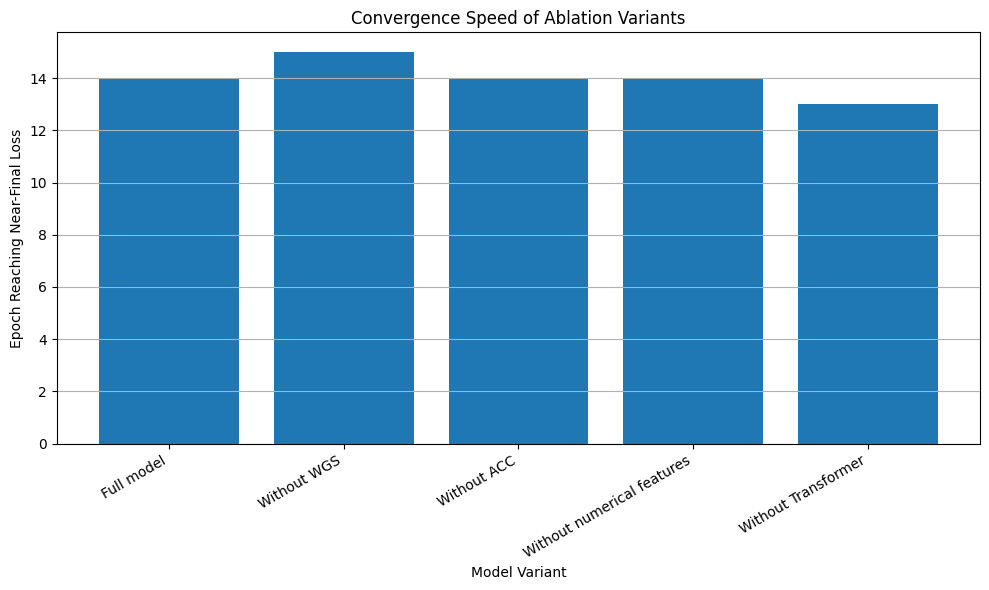

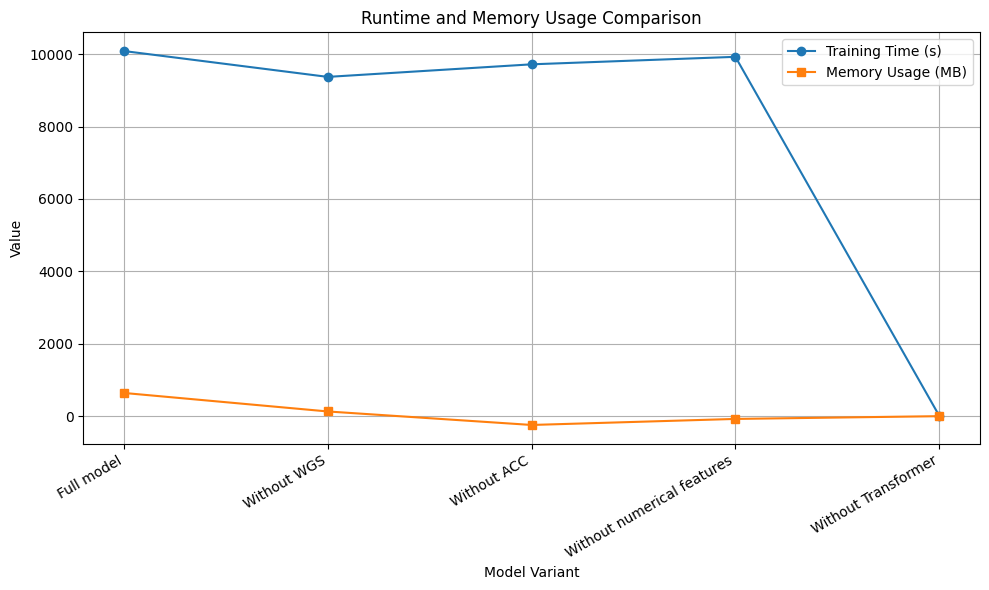

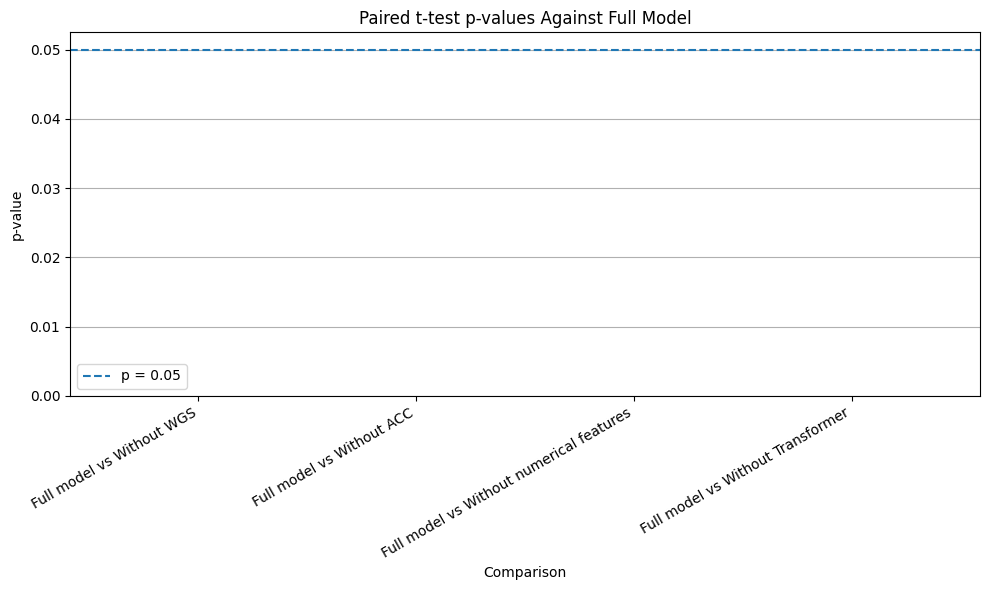


Ablation study completed.
Generated files:
- ablation_outputs/ablation_study_results.csv
- ablation_outputs/ablation_study_results_clean.csv
- ablation_outputs/ablation_ttest_results.csv
- ablation_outputs/training_loss_curves.png
- ablation_outputs/ablation_performance_comparison.png
- ablation_outputs/convergence_speed_comparison.png
- ablation_outputs/runtime_memory_comparison.png
- ablation_outputs/ttest_pvalues_comparison.png


In [33]:
# ============================================================
# POINT 8 - ADVANCED ABLATION STUDY FOR TRANSFORMERREGRESSOR
# Logs + Runtime + Memory + Convergence Speed + T-test + Figures
# Corrected version without tensor / numpy warnings
# ============================================================

import os
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ttest_rel

# ------------------------------------------------------------
# 0. Output directory
# ------------------------------------------------------------

OUTPUT_DIR = "ablation_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ------------------------------------------------------------
# 1. Utilities
# ------------------------------------------------------------

def get_memory_usage_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)


def to_numpy_float32(x):
    """
    Safely converts tensors, lists, pandas objects, or numpy arrays to float32 numpy arrays.
    Avoids numpy/tensor copy warnings.
    """
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().astype(np.float32)
    return np.asarray(x, dtype=np.float32)


def to_long_tensor(x):
    """
    Safely converts a pattern sequence to torch.long tensor.
    Avoids torch.tensor(tensor) warnings.
    """
    if torch.is_tensor(x):
        return x.detach().clone().long()
    return torch.as_tensor(x, dtype=torch.long)


def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    pearsons = []
    for i in range(y_true.shape[1]):
        if np.std(y_true[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
            pearsons.append(np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1])

    pearson = float(np.mean(pearsons)) if pearsons else np.nan
    return mae, rmse, pearson


def per_sample_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred), axis=1)


def convergence_epoch(losses, tolerance=0.05):
    """
    Returns the first epoch where the loss reaches within 5% of final loss.
    Lower value = faster convergence.
    """
    final_loss = losses[-1]
    threshold = final_loss * (1 + tolerance)

    for idx, loss in enumerate(losses):
        if loss <= threshold:
            return idx + 1

    return len(losses)


# ------------------------------------------------------------
# 2. Dataset
# ------------------------------------------------------------

class AblationMotifDataset(Dataset):
    def __init__(self, dataset, normalize=True):
        self.patterns = dataset["patterns"]

        self.gs = to_numpy_float32(dataset["gs"])
        self.wgs = to_numpy_float32(dataset["wgs"])
        self.acc = to_numpy_float32(dataset["acc"])

        if normalize:
            scaler_gs = MinMaxScaler()
            scaler_wgs = MinMaxScaler()
            scaler_acc = MinMaxScaler()

            self.gs = scaler_gs.fit_transform(self.gs.reshape(-1, 1)).flatten()
            self.wgs = scaler_wgs.fit_transform(self.wgs.reshape(-1, 1)).flatten()
            self.acc = scaler_acc.fit_transform(self.acc.reshape(-1, 1)).flatten()

        self.targets = np.vstack([self.gs, self.wgs, self.acc]).T.astype(np.float32)

    def __len__(self):
        return len(self.gs)

    def __getitem__(self, idx):
        pattern = to_long_tensor(self.patterns[idx])

        return {
            "patterns": pattern,
            "gs": torch.as_tensor(self.gs[idx], dtype=torch.float32),
            "wgs": torch.as_tensor(self.wgs[idx], dtype=torch.float32),
            "acc": torch.as_tensor(self.acc[idx], dtype=torch.float32),
            "targets": torch.as_tensor(self.targets[idx], dtype=torch.float32)
        }


full_dataset = AblationMotifDataset(dataset_tensors, normalize=True)

train_size = int(0.70 * len(full_dataset))
test_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Dataset size: {len(full_dataset)}")
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")


# ------------------------------------------------------------
# 3. Model
# ------------------------------------------------------------

class AblationTransformerRegressor(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        num_heads=4,
        num_layers=2,
        ff_dim=256,
        output_dim=3,
        use_transformer=True,
        use_gs=True,
        use_wgs=True,
        use_acc=True
    ):
        super().__init__()

        self.use_transformer = use_transformer
        self.use_gs = use_gs
        self.use_wgs = use_wgs
        self.use_acc = use_acc

        self.num_numeric = int(use_gs) + int(use_wgs) + int(use_acc)

        if self.use_transformer:
            self.embedding = nn.Embedding(vocab_size, embed_dim)

            encoder_layer = nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=0.1,
                batch_first=True
            )

            self.transformer_encoder = nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )

        if self.num_numeric > 0:
            self.fc_numeric = nn.Linear(self.num_numeric, embed_dim)

        self.fc_out = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, output_dim)
        )

    def forward(self, patterns, gs, wgs, acc):
        numeric_list = []

        if self.use_gs:
            numeric_list.append(gs.unsqueeze(1))
        if self.use_wgs:
            numeric_list.append(wgs.unsqueeze(1))
        if self.use_acc:
            numeric_list.append(acc.unsqueeze(1))

        representation = None

        if self.use_transformer:
            embedded = self.embedding(patterns)
            transformer_output = self.transformer_encoder(embedded)
            representation = transformer_output[:, 0, :]

        if self.num_numeric > 0:
            numeric_features = torch.cat(numeric_list, dim=1)
            numeric_embedding = self.fc_numeric(numeric_features)

            if representation is None:
                representation = numeric_embedding
            else:
                representation = representation + numeric_embedding

        return self.fc_out(representation)


# ------------------------------------------------------------
# 4. Loss function
# ------------------------------------------------------------

def weighted_huber_loss_multi(preds, targets, delta=1.0):
    huber = nn.HuberLoss(delta=delta, reduction="none")
    loss = huber(preds, targets)

    # Higher weight for high-support patterns
    weights = torch.where(targets[:, 0:1] >= 0.66, 2.0, 1.0)

    return (loss * weights).mean()


# ------------------------------------------------------------
# 5. Training and evaluation
# ------------------------------------------------------------

def train_model(model, train_loader, epochs=15, lr=1e-4, variant_name="Model"):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []

    start_time = time.time()
    start_memory = get_memory_usage_mb()

    print(f"\n====================================================")
    print(f"Training variant: {variant_name}")
    print(f"====================================================")

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for batch in train_loader:
            patterns = batch["patterns"].to(device)
            gs = batch["gs"].to(device)
            wgs = batch["wgs"].to(device)
            acc = batch["acc"].to(device)
            targets = batch["targets"].to(device)

            optimizer.zero_grad()
            outputs = model(patterns, gs, wgs, acc)

            loss = weighted_huber_loss_multi(outputs, targets)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {avg_loss:.6f}")

    end_time = time.time()
    end_memory = get_memory_usage_mb()

    training_time = end_time - start_time
    memory_delta = end_memory - start_memory
    conv_epoch = convergence_epoch(epoch_losses, tolerance=0.05)

    print(f"Completed: {variant_name}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Memory variation: {memory_delta:.2f} MB")
    print(f"Convergence epoch: {conv_epoch}")

    return {
        "losses": epoch_losses,
        "training_time": training_time,
        "memory_usage": memory_delta,
        "convergence_epoch": conv_epoch
    }


def evaluate_model(model, test_loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in test_loader:
            patterns = batch["patterns"].to(device)
            gs = batch["gs"].to(device)
            wgs = batch["wgs"].to(device)
            acc = batch["acc"].to(device)

            targets = batch["targets"].cpu().numpy()
            outputs = model(patterns, gs, wgs, acc).cpu().numpy()

            y_true.append(targets)
            y_pred.append(outputs)

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    mae, rmse, pearson = compute_metrics(y_true, y_pred)
    sample_errors = per_sample_absolute_error(y_true, y_pred)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "mae": mae,
        "rmse": rmse,
        "pearson": pearson,
        "sample_errors": sample_errors
    }


# ------------------------------------------------------------
# 6. Ablation configurations
# ------------------------------------------------------------

vocab_size = max([max(seq) for seq in dataset_tensors["patterns"] if len(seq) > 0]) + 1

ablation_configs = [
    {"Variant": "Full model", "use_transformer": True, "use_gs": True, "use_wgs": True, "use_acc": True},
    {"Variant": "Without WGS", "use_transformer": True, "use_gs": True, "use_wgs": False, "use_acc": True},
    {"Variant": "Without ACC", "use_transformer": True, "use_gs": True, "use_wgs": True, "use_acc": False},
    {"Variant": "Without numerical features", "use_transformer": True, "use_gs": False, "use_wgs": False, "use_acc": False},
    {"Variant": "Without Transformer", "use_transformer": False, "use_gs": True, "use_wgs": True, "use_acc": True}
]


# ------------------------------------------------------------
# 7. Run ablation study
# ------------------------------------------------------------

ablation_results = []
loss_history = {}
prediction_errors = {}

for config in ablation_configs:
    variant_name = config["Variant"]

    model = AblationTransformerRegressor(
        vocab_size=vocab_size,
        embed_dim=128,
        num_heads=4,
        num_layers=2,
        ff_dim=256,
        output_dim=3,
        use_transformer=config["use_transformer"],
        use_gs=config["use_gs"],
        use_wgs=config["use_wgs"],
        use_acc=config["use_acc"]
    )

    train_info = train_model(
        model,
        train_loader,
        epochs=15,
        lr=1e-4,
        variant_name=variant_name
    )

    eval_info = evaluate_model(model, test_loader)

    loss_history[variant_name] = train_info["losses"]
    prediction_errors[variant_name] = eval_info["sample_errors"]

    ablation_results.append({
        "Model Variant": variant_name,
        "MAE": eval_info["mae"],
        "RMSE": eval_info["rmse"],
        "Pearson": eval_info["pearson"],
        "Training Time (s)": train_info["training_time"],
        "Memory Usage (MB)": train_info["memory_usage"],
        "Convergence Epoch": train_info["convergence_epoch"]
    })


ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

ablation_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_study_results.csv"), index=False)
ablation_df.round(6).to_csv(os.path.join(OUTPUT_DIR, "ablation_study_results_clean.csv"), index=False)

print("\nAblation study results saved.")


# ------------------------------------------------------------
# 8. Statistical tests: paired t-test against Full model
# ------------------------------------------------------------

statistical_results = []
full_errors = prediction_errors.get("Full model")

if full_errors is not None:
    for variant, errors in prediction_errors.items():
        if variant == "Full model":
            continue

        t_stat, p_value = ttest_rel(full_errors, errors)

        statistical_results.append({
            "Comparison": f"Full model vs {variant}",
            "t-statistic": t_stat,
            "p-value": p_value,
            "Significant (p < 0.05)": p_value < 0.05
        })

statistical_df = pd.DataFrame(statistical_results)
display(statistical_df)

statistical_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_ttest_results.csv"), index=False)


# ------------------------------------------------------------
# 9. Plot 1: Training loss curves
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for variant, losses in loss_history.items():
    plt.plot(range(1, len(losses) + 1), losses, marker="o", label=variant)

plt.title("Training Loss Curves for Ablation Variants")
plt.xlabel("Epoch")
plt.ylabel("Weighted Huber Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_loss_curves.png"), dpi=300)
plt.show()


# ------------------------------------------------------------
# 10. Plot 2: Ablation performance comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(ablation_df["Model Variant"], ablation_df["MAE"], marker="o", label="MAE")
plt.plot(ablation_df["Model Variant"], ablation_df["RMSE"], marker="s", label="RMSE")
plt.title("Ablation Study Performance Comparison")
plt.xlabel("Model Variant")
plt.ylabel("Error")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ablation_performance_comparison.png"), dpi=300)
plt.show()


# ------------------------------------------------------------
# 11. Plot 3: Convergence speed
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(ablation_df["Model Variant"], ablation_df["Convergence Epoch"])
plt.title("Convergence Speed of Ablation Variants")
plt.xlabel("Model Variant")
plt.ylabel("Epoch Reaching Near-Final Loss")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "convergence_speed_comparison.png"), dpi=300)
plt.show()


# ------------------------------------------------------------
# 12. Plot 4: Runtime and memory comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(ablation_df["Model Variant"], ablation_df["Training Time (s)"], marker="o", label="Training Time (s)")
plt.plot(ablation_df["Model Variant"], ablation_df["Memory Usage (MB)"], marker="s", label="Memory Usage (MB)")
plt.title("Runtime and Memory Usage Comparison")
plt.xlabel("Model Variant")
plt.ylabel("Value")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "runtime_memory_comparison.png"), dpi=300)
plt.show()


# ------------------------------------------------------------
# 13. Plot 5: t-test p-values
# ------------------------------------------------------------

if len(statistical_df) > 0:
    plt.figure(figsize=(10, 6))
    plt.bar(statistical_df["Comparison"], statistical_df["p-value"])
    plt.axhline(y=0.05, linestyle="--", label="p = 0.05")
    plt.title("Paired t-test p-values Against Full Model")
    plt.xlabel("Comparison")
    plt.ylabel("p-value")
    plt.xticks(rotation=30, ha="right")
    plt.legend()
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ttest_pvalues_comparison.png"), dpi=300)
    plt.show()


# ------------------------------------------------------------
# 14. Final logs
# ------------------------------------------------------------

print("\n====================================================")
print("Ablation study completed.")
print("Generated files:")
print(f"- {OUTPUT_DIR}/ablation_study_results.csv")
print(f"- {OUTPUT_DIR}/ablation_study_results_clean.csv")
print(f"- {OUTPUT_DIR}/ablation_ttest_results.csv")
print(f"- {OUTPUT_DIR}/training_loss_curves.png")
print(f"- {OUTPUT_DIR}/ablation_performance_comparison.png")
print(f"- {OUTPUT_DIR}/convergence_speed_comparison.png")
print(f"- {OUTPUT_DIR}/runtime_memory_comparison.png")
print(f"- {OUTPUT_DIR}/ttest_pvalues_comparison.png")
print("====================================================")

### Nous allons entraîner notre modèle avec un optimiseur Adam et une Binary Cross Entropy Loss (BCE).
1️⃣ Définir la fonction de perte et l'optimiseur

### ✅ Nouvelle définition des fonctions de perte (adaptées à multi-target regression) :

In [34]:
import torch.nn as nn
import torch

# Fonction Huber pondérée pour les 3 sorties
def weighted_huber_loss(preds, targets, delta=0.1):
    """
    preds : Tensor [batch_size, 3]
    targets : Tensor [batch_size, 3]
    """
    huber = nn.HuberLoss(delta=delta, reduction='none')
    loss = huber(preds, targets)  # Shape : [batch_size, 3]

    # Pondération personnalisée par sortie
    weights = torch.ones_like(targets)

    # Exemple : augmenter le poids de certaines cibles spécifiques (ex: GS ≈ 1.0 ou 0.66)
    weights[:, 0] = torch.where((targets[:, 0] == 1.00) | (targets[:, 0] == 0.66), 2.0, 1.0)  # GS
    weights[:, 1] = torch.where(targets[:, 1] >= 0.83, 2.0, 1.0)  # WGS élevé
    weights[:, 2] = 1.0  # ACC non pondéré

    weighted_loss = (loss * weights).mean()
    return weighted_loss

In [35]:
criterion = nn.SmoothL1Loss(beta=0.05)  # S'applique directement sur [batch_size, 3]

In [36]:
import torch.optim as optim


In [37]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [38]:
print("Valeurs max des tokens :", max([max(seq) for seq in dataset_tensors["patterns"] if len(seq) > 0]))
print("Vocab size attendu :", vocab_size)


Valeurs max des tokens : tensor(30918)
Vocab size attendu : tensor(30919)


## ✅ Objectif : Entraîner le modèle sur plusieurs époques et suivre l'évolution de la perte.

In [39]:
loss_history = []
mae_history = []
rmse_history = []

In [40]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm

# Initialisation
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

loss_history, mae_history, rmse_history, lr_history = [], [], [], []
num_epochs = 15
model.train()

for epoch in range(num_epochs):
    epoch_loss = 0
    all_preds, all_targets = [], []

    for batch in tqdm(train_loader, desc=f"Époque Train {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()
        patterns = batch["patterns"].to(device)
        gs = batch["gs"].to(device)
        wgs = batch["wgs"].to(device)
        acc = batch["acc"].to(device)

        # Regrouper les cibles en une seule matrice [batch_size, 3]
        targets = torch.stack([gs, wgs, acc], dim=1)

        # Forward pass (la sortie est maintenant [batch_size, 3])
        outputs = model(patterns, gs, wgs, acc)

        # Calcul de la perte
        loss = weighted_huber_loss(outputs, targets)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        all_preds.append(outputs.detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())

    scheduler.step()

    # Concaténation pour métriques globales
    preds = np.vstack(all_preds)
    targets = np.vstack(all_targets)
    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    current_lr = scheduler.get_last_lr()[0]

    loss_history.append(epoch_loss)
    mae_history.append(mae)
    rmse_history.append(rmse)
    lr_history.append(current_lr)

    print(f"📊 Epoch Train {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - MAE: {mae:.4f} - RMSE: {rmse:.4f} - LR: {current_lr:.6f}")


Époque Train 1/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 327/327 [00:00<00:00, 351.41it/s]


📊 Epoch Train 1/15 - Loss: 0.0392 - MAE: 0.0096 - RMSE: 0.0156 - LR: 0.001000


Époque Train 2/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 327/327 [00:00<00:00, 354.86it/s]


📊 Epoch Train 2/15 - Loss: 0.0335 - MAE: 0.0085 - RMSE: 0.0144 - LR: 0.001000


Époque Train 3/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 327/327 [00:00<00:00, 366.14it/s]


...

📊 Epoch Train 13/15 - Loss: 0.0184 - MAE: 0.0053 - RMSE: 0.0107 - LR: 0.000250


Époque Train 14/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 327/327 [00:00<00:00, 355.34it/s]


📊 Epoch Train 14/15 - Loss: 0.0188 - MAE: 0.0053 - RMSE: 0.0108 - LR: 0.000250


Époque Train 15/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 327/327 [00:00<00:00, 354.46it/s]

📊 Epoch Train 15/15 - Loss: 0.0216 - MAE: 0.0056 - RMSE: 0.0117 - LR: 0.000125


/tmp/ipykernel_18828/3406523619.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/fotso/Documents/gitlab/UPDATED/SequuentialGradualPatternApproch/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


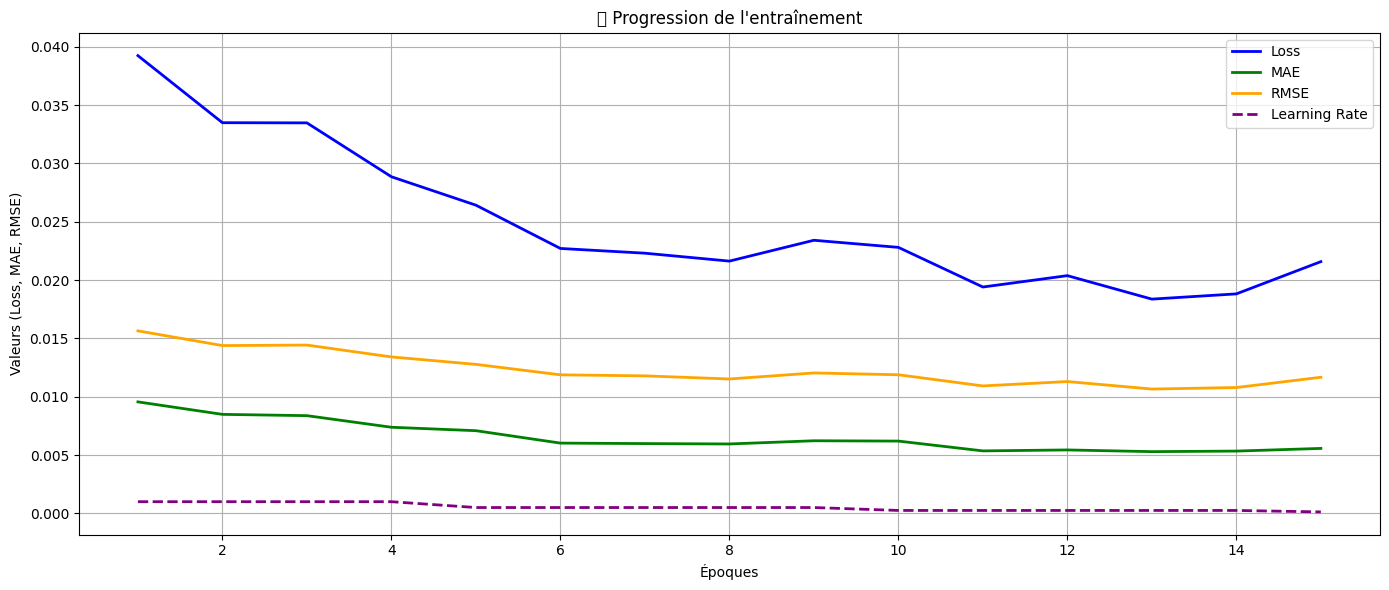

In [41]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(14, 6))

# 🔹 Courbes de performance
plt.plot(epochs, loss_history, label="Loss", color="blue", linewidth=2)
plt.plot(epochs, mae_history, label="MAE", color="green", linewidth=2)
plt.plot(epochs, rmse_history, label="RMSE", color="orange", linewidth=2)

# 🔹 Courbe du taux d'apprentissage (échelle secondaire)
plt.plot(epochs, lr_history, label="Learning Rate", color="purple", linestyle="dashed", linewidth=2)

plt.title("📈 Progression de l'entraînement")
plt.xlabel("Époques")
plt.ylabel("Valeurs (Loss, MAE, RMSE)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for batch in test_loader:
        patterns = batch["patterns"].to(device)
        gs = batch["gs"].to(device)
        wgs = batch["wgs"].to(device)
        acc = batch["acc"].to(device)

        targets = torch.stack([gs, wgs, acc], dim=1)  # cibles
        outputs = model(patterns, gs, wgs, acc)       # prédictions

        all_preds.append(outputs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

# Concaténer tous les résultats
all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# 🔢 Calcul des métriques
mae = mean_absolute_error(all_targets, all_preds, multioutput='raw_values')
rmse = np.sqrt(mean_squared_error(all_targets, all_preds, multioutput='raw_values'))

print("\n📊 Évaluation finale sur le jeu de test :")
for i, name in enumerate(["GS", "WGS", "ACC"]):
    print(f"🔹 {name} → MAE: {mae[i]:.4f}, RMSE: {rmse[i]:.4f}")



📊 Évaluation finale sur le jeu de test :
🔹 GS → MAE: 0.0023, RMSE: 0.0045
🔹 WGS → MAE: 0.0014, RMSE: 0.0020
🔹 ACC → MAE: 0.0035, RMSE: 0.0042


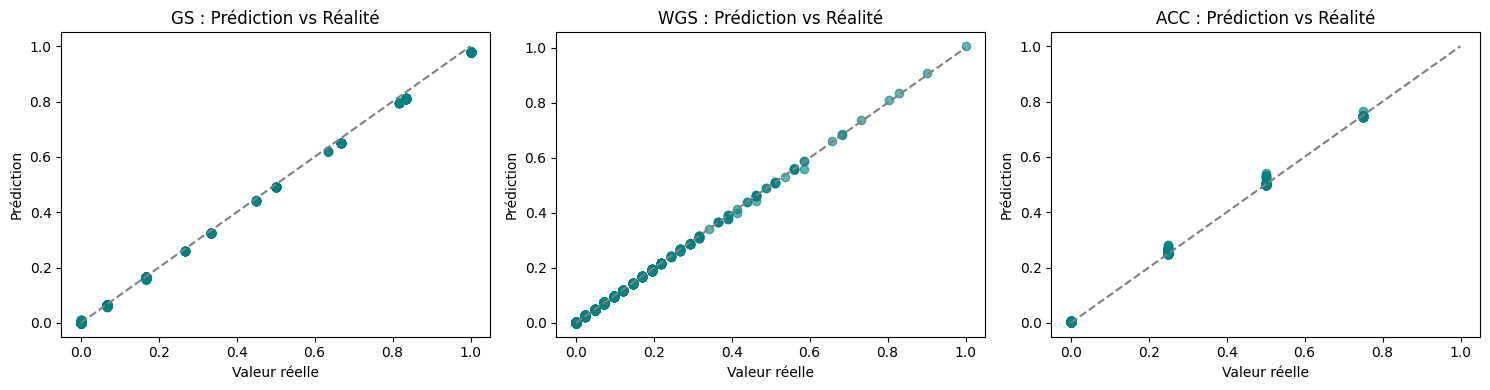

In [43]:
import matplotlib.pyplot as plt

names = ["GS", "WGS", "ACC"]
plt.figure(figsize=(15, 4))

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.scatter(all_targets[:, i], all_preds[:, i], alpha=0.6, color='teal')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel("Valeur réelle")
    plt.ylabel("Prédiction")
    plt.title(f"{names[i]} : Prédiction vs Réalité")

plt.tight_layout()
plt.show()


In [44]:
from scipy.stats import pearsonr

print("\n📊 Évaluation finale sur le jeu de test :")
for i, name in enumerate(["GS", "WGS", "ACC"]):
    mae_i = mae[i]
    rmse_i = rmse[i]
    corr_i, _ = pearsonr(all_targets[:, i], all_preds[:, i])

    print(f"🔹 {name} → MAE: {mae_i:.4f}, RMSE: {rmse_i:.4f}, Corrélation: {corr_i:.4f}")



📊 Évaluation finale sur le jeu de test :
🔹 GS → MAE: 0.0023, RMSE: 0.0045, Corrélation: 1.0000
🔹 WGS → MAE: 0.0014, RMSE: 0.0020, Corrélation: 0.9997
🔹 ACC → MAE: 0.0035, RMSE: 0.0042, Corrélation: 0.9999


/tmp/ipykernel_18828/511482789.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="Variable", y="MAE", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_18828/511482789.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="Variable", y="RMSE", ax=axes[1], palette="Greens_d")
/tmp/ipykernel_18828/511482789.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="Variable", y="Corrélation", ax=axes[2], palette="Reds_d")
/tmp/ipykernel_18828/511482789.py:42: UserWarning: Glyph 128200 (\N{CHART

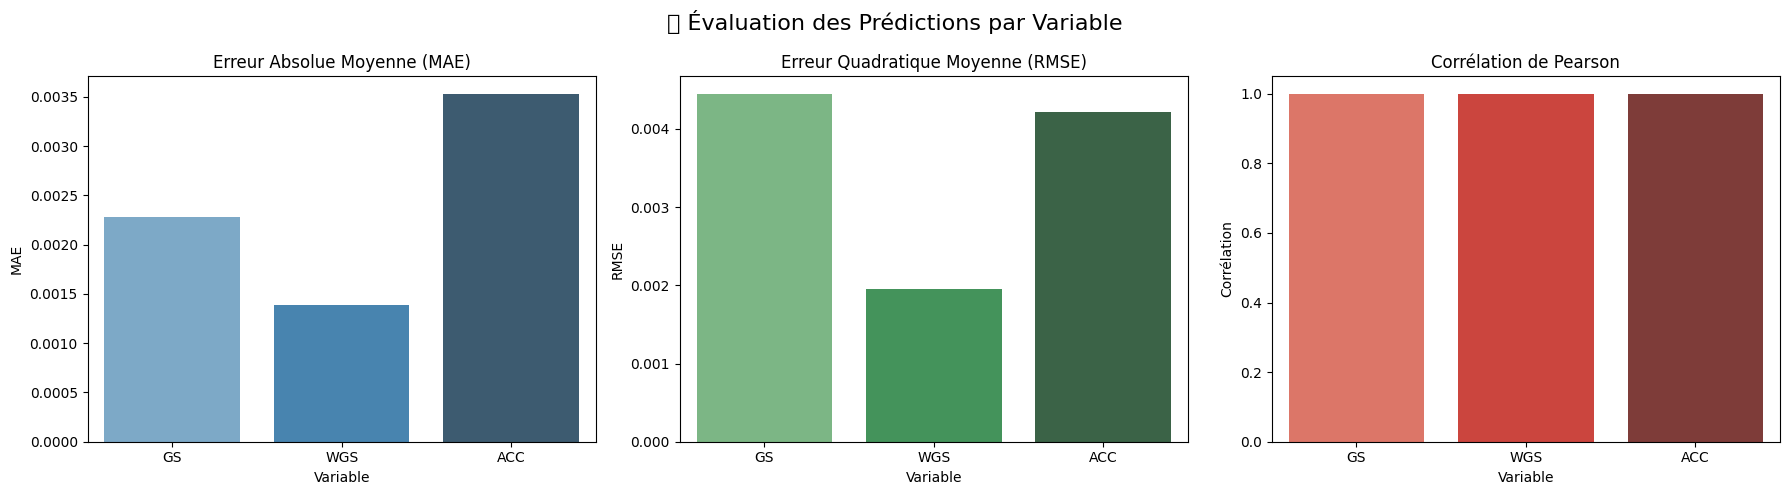

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

# Suppose que all_preds et all_targets sont déjà concaténés sur tout le test set
# (shape: [n_samples, 3])
mae_list = []
rmse_list = []
corr_list = []
labels = ["GS", "WGS", "ACC"]

for i in range(3):
    pred = all_preds[:, i]
    target = all_targets[:, i]
    mae_list.append(mean_absolute_error(target, pred))
    rmse_list.append(np.sqrt(mean_squared_error(target, pred)))
    corr_list.append(pearsonr(target, pred)[0])

# Création d’un DataFrame pour seaborn
import pandas as pd
df_metrics = pd.DataFrame({
    "Variable": labels,
    "MAE": mae_list,
    "RMSE": rmse_list,
    "Corrélation": corr_list
})

# 📊 Tracer les 3 métriques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_metrics, x="Variable", y="MAE", ax=axes[0], palette="Blues_d")
axes[0].set_title("Erreur Absolue Moyenne (MAE)")

sns.barplot(data=df_metrics, x="Variable", y="RMSE", ax=axes[1], palette="Greens_d")
axes[1].set_title("Erreur Quadratique Moyenne (RMSE)")

sns.barplot(data=df_metrics, x="Variable", y="Corrélation", ax=axes[2], palette="Reds_d")
axes[2].set_title("Corrélation de Pearson")

plt.suptitle("📈 Évaluation des Prédictions par Variable", fontsize=16)
plt.tight_layout()
plt.show()


# Cross validation k-fold

In [46]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [47]:
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):
    print(f"\n🔁 Fold {fold+1}/{k_folds}")

    train_sub = Subset(train_dataset, train_idx)
    val_sub = Subset(train_dataset, val_idx)

    train_loader = DataLoader(train_sub, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_sub, batch_size=16, shuffle=False)

    model = TransformerRegressor(vocab_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    num_epochs = 10
    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            patterns = batch["patterns"].to(device)
            gs = batch["gs"].to(device)
            wgs = batch["wgs"].to(device)
            acc = batch["acc"].to(device)
            targets = torch.stack([gs, wgs, acc], dim=1)
            outputs = model(patterns, gs, wgs, acc)
            loss = weighted_huber_loss(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

    # Évaluation sur validation
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in val_loader:
            patterns = batch["patterns"].to(device)
            gs = batch["gs"].to(device)
            wgs = batch["wgs"].to(device)
            acc = batch["acc"].to(device)
            targets = torch.stack([gs, wgs, acc], dim=1)
            outputs = model(patterns, gs, wgs, acc)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    preds = np.vstack(all_preds)
    targets = np.vstack(all_targets)
    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))

    print(f"✅ Fold {fold+1} - MAE: {mae:.4f} - RMSE: {rmse:.4f}")
    fold_results.append((mae, rmse))


/tmp/ipykernel_18828/3392345524.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(



🔁 Fold 1/5
✅ Fold 1 - MAE: 0.0029 - RMSE: 0.0031

🔁 Fold 2/5


/tmp/ipykernel_18828/3392345524.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(


✅ Fold 2 - MAE: 0.0025 - RMSE: 0.0028

🔁 Fold 3/5


/tmp/ipykernel_18828/3392345524.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(


✅ Fold 3 - MAE: 0.0011 - RMSE: 0.0014

🔁 Fold 4/5


/tmp/ipykernel_18828/3392345524.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(


✅ Fold 4 - MAE: 0.0023 - RMSE: 0.0029

🔁 Fold 5/5


/tmp/ipykernel_18828/3392345524.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(


✅ Fold 5 - MAE: 0.0028 - RMSE: 0.0033


## 📌 Étape 4 : Évaluation

Une fois l'entraînement terminé, évaluons la performance du modèle.
### 1️⃣ Tester sur un batch de validation
✅ Objectif : Vérifier si le modèle fait des prédictions cohérentes.

In [49]:
eval_loader = test_loader

In [50]:
model.eval()
with torch.no_grad():
    for batch in eval_loader:
        patterns = batch["patterns"].to(device)
        gs = batch["gs"].to(device)
        wgs = batch["wgs"].to(device)
        acc = batch["acc"].to(device)

        outputs = model(patterns, gs, wgs, acc).squeeze()
        print("Prédictions :", outputs)
        print("Valeurs réelles :", gs)  # Exemple
        break


Prédictions : tensor([[-0.0016, -0.0013, -0.0047],
        [ 0.1647, -0.0010,  0.2445],
        [-0.0016,  0.0231, -0.0048],
        [-0.0016,  0.0231, -0.0048],
        [ 0.1647, -0.0010,  0.2445],
        [-0.0015,  0.0474, -0.0050],
        [-0.0016, -0.0013, -0.0047],
        [-0.0016, -0.0013, -0.0047],
        [-0.0018,  0.2666,  0.2424],
        [-0.0016,  0.0231, -0.0048],
        [ 0.1647, -0.0010,  0.2445],
        [ 0.0647,  0.0962,  0.2436],
        [-0.0016, -0.0013, -0.0047],
        [-0.0016, -0.0013, -0.0047],
        [-0.0016, -0.0013, -0.0047],
        [-0.0019,  0.1935,  0.2428],
        [-0.0016,  0.0231, -0.0048],
        [-0.0016, -0.0013, -0.0047],
        [ 0.1647,  0.0234,  0.2443],
        [-0.0016, -0.0013, -0.0047],
        [-0.0016,  0.0231, -0.0048],
        [-0.0016, -0.0013, -0.0047],
        [-0.0016, -0.0013, -0.0047],
        [-0.0016, -0.0013, -0.0047],
        [-0.0016, -0.0013, -0.0047],
        [-0.0016,  0.0231, -0.0048],
        [-0.0016, -0.001

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import numpy as np

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in dataloader:
            patterns = batch["patterns"].to(device)
            gs = batch["gs"].to(device)

            # Faire une prédiction
            outputs = model(patterns, batch["gs"].to(device), batch["wgs"].to(device), batch["acc"].to(device)).squeeze()

            # Collecter les résultats
            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(gs.cpu().numpy())

    # Convertir en array numpy
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Calcul des métriques
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    corr, _ = pearsonr(all_targets, all_preds)

    print("📊 Évaluation du modèle :")
    print(f"🔹 MAE  : {mae:.4f}")
    print(f"🔹 RMSE : {rmse:.4f}")
    print(f"🔹 Corrélation : {corr:.4f}")

    return mae, rmse, corr


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import numpy as np
import torch

def evaluate_model_multioutput(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in dataloader:
            patterns = batch["patterns"].to(device)
            gs = batch["gs"].to(device)
            wgs = batch["wgs"].to(device)
            acc = batch["acc"].to(device)
            targets = batch["targets"].to(device)   # GS, WGS, ACC

            outputs = model(patterns, gs, wgs, acc)

            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))

    pearsons = []
    target_names = ["GS", "WGS", "ACC"]

    print("📊 Multi-output model evaluation:")
    for i, name in enumerate(target_names):
        mae_i = mean_absolute_error(all_targets[:, i], all_preds[:, i])
        rmse_i = np.sqrt(mean_squared_error(all_targets[:, i], all_preds[:, i]))

        if np.std(all_targets[:, i]) > 0 and np.std(all_preds[:, i]) > 0:
            corr_i, _ = pearsonr(all_targets[:, i], all_preds[:, i])
        else:
            corr_i = np.nan

        pearsons.append(corr_i)

        print(f"{name}: MAE={mae_i:.4f}, RMSE={rmse_i:.4f}, Pearson={corr_i:.4f}")

    corr = np.nanmean(pearsons)

    print("\n📌 Global scores:")
    print(f"MAE     : {mae:.4f}")
    print(f"RMSE    : {rmse:.4f}")
    print(f"Pearson : {corr:.4f}")

    return mae, rmse, corr, all_targets, all_preds

In [54]:
#evaluate_model(model, eval_loader, device)
mae, rmse, corr, y_true, y_pred = evaluate_model_multioutput(model, eval_loader, device)

📊 Multi-output model evaluation:
GS: MAE=0.0017, RMSE=0.0017, Pearson=1.0000
WGS: MAE=0.0013, RMSE=0.0013, Pearson=1.0000
ACC: MAE=0.0052, RMSE=0.0053, Pearson=1.0000

📌 Global scores:
MAE     : 0.0028
RMSE    : 0.0033
Pearson : 1.0000


> # evaluation 

In [56]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
# import seaborn as sns
# import numpy as np

# model.eval()
# all_preds = []
# all_targets = []

# with torch.no_grad():
#     for batch in eval_loader:
#         patterns = batch["patterns"].to(device)
#         gs = batch["gs"].to(device)  # ou `targets` selon ta variable
#         wgs = batch["wgs"].to(device)
#         acc = batch["acc"].to(device)

#         outputs = model(patterns, gs, wgs, acc).squeeze()
#         all_preds.extend(outputs.cpu().numpy())
#         all_targets.extend(gs.cpu().numpy())

# # Convertir en arrays
# preds = np.array(all_preds)
# targets = np.array(all_targets)

# # ✅ 1. Graphe des prédictions
# plt.figure(figsize=(12, 4))
# plt.plot(preds, label="Prédictions")
# plt.plot(targets, label="Valeurs réelles")
# plt.title("Comparaison Prédictions vs Réalité")
# plt.legend()
# plt.grid(True)
# plt.show()

# # ✅ 2. Erreurs (résidus)
# errors = preds - targets
# sns.histplot(errors, kde=True)
# plt.title("Distribution des erreurs (résidus)")
# plt.xlabel("Erreur (Prédiction - Réalité)")
# plt.show()

# # ✅ 3. Scatter Plot
# plt.figure(figsize=(6, 6))
# plt.scatter(targets, preds, alpha=0.5)
# plt.plot([0, 1], [0, 1], color='red', linestyle="--")
# plt.title("Scatter Plot : Prédit vs Réel")
# plt.xlabel("Valeur Réelle")
# plt.ylabel("Prédiction")
# plt.grid(True)
# plt.show()

# # ✅ 4. Matrice de confusion (si classification binaire)
# y_pred_labels = (preds > 0.5).astype(int)
# y_true_labels = (targets > 0.5).astype(int)

# cm = confusion_matrix(y_true_labels, y_pred_labels)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.title("Matrice de Confusion")
# plt.show()

# # ✅ 5. Rapport de classification
# print("Rapport de classification :")
# print(classification_report(y_true_labels, y_pred_labels))


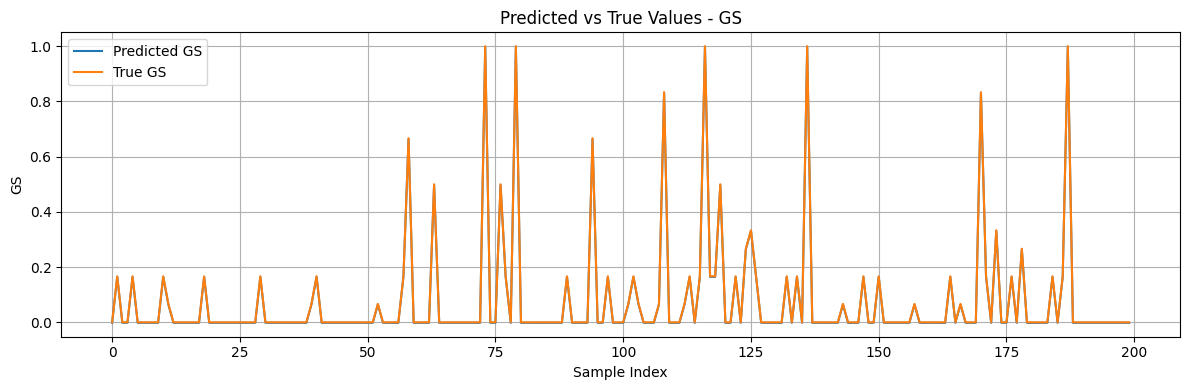

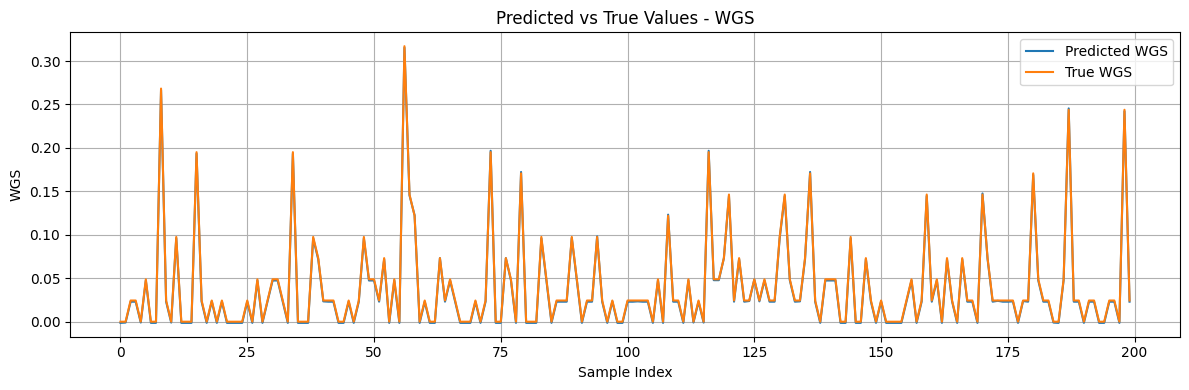

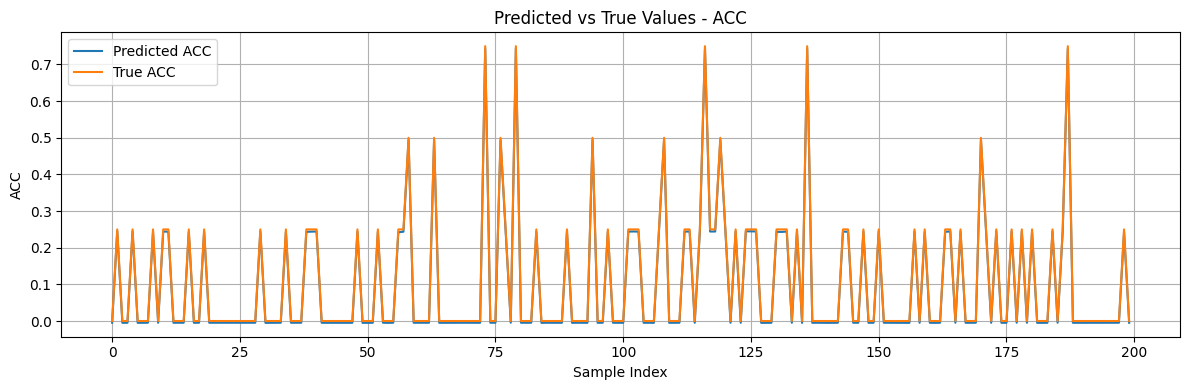

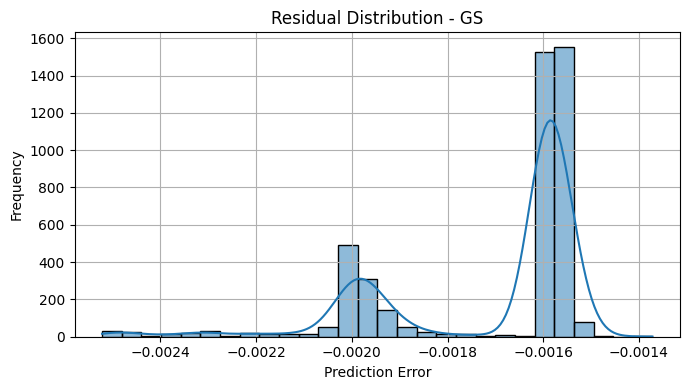

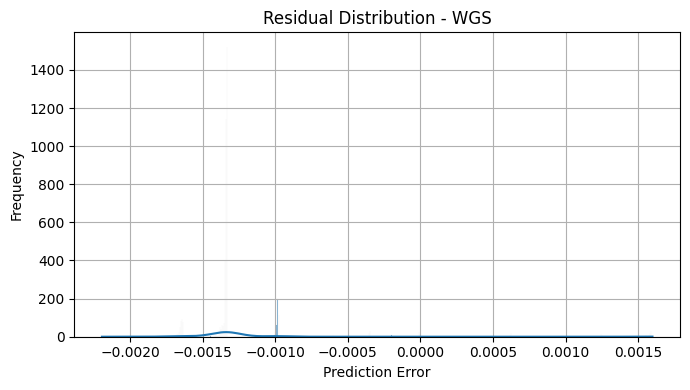

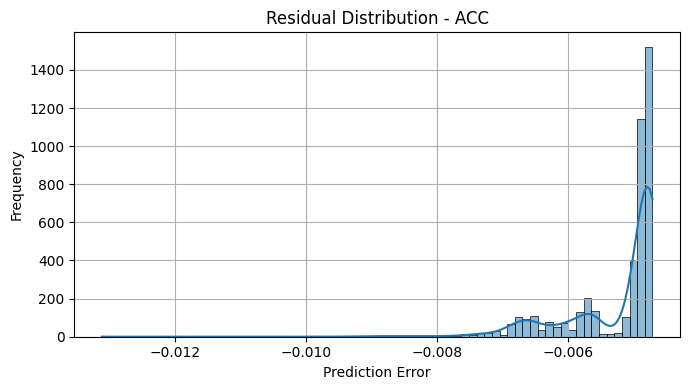

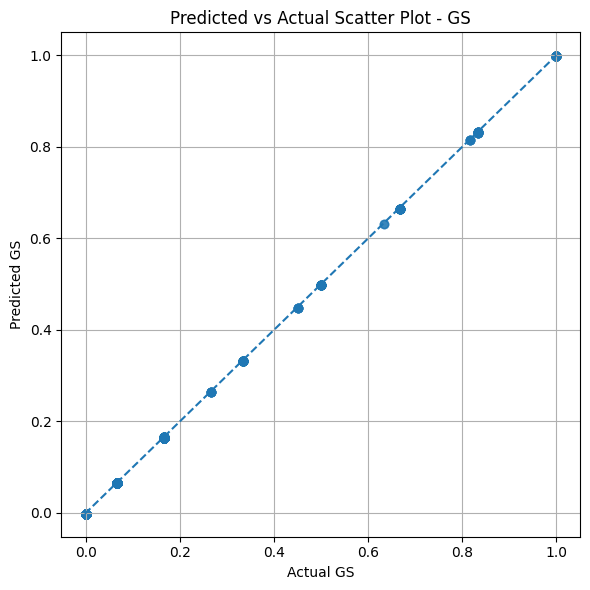

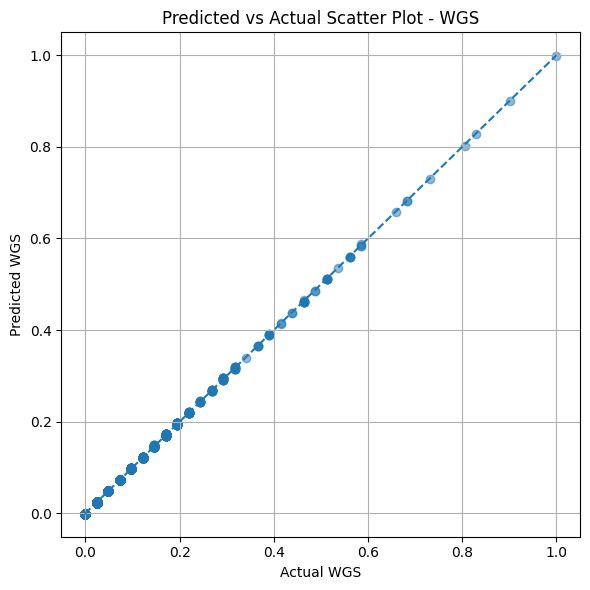

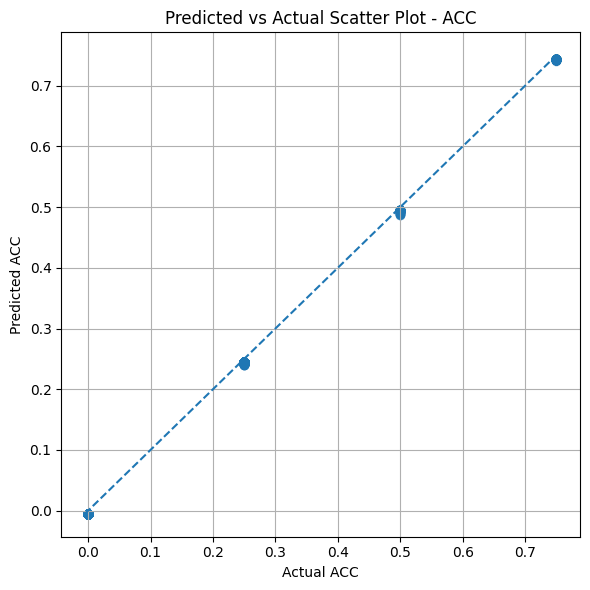

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in eval_loader:
        patterns = batch["patterns"].to(device)
        gs = batch["gs"].to(device)
        wgs = batch["wgs"].to(device)
        acc = batch["acc"].to(device)
        targets = batch["targets"].to(device)  # GS, WGS, ACC

        outputs = model(patterns, gs, wgs, acc)

        all_preds.append(outputs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

preds = np.vstack(all_preds)
targets = np.vstack(all_targets)

target_names = ["GS", "WGS", "ACC"]

# 1. Prediction vs real curves
for i, name in enumerate(target_names):
    plt.figure(figsize=(12, 4))
    plt.plot(preds[:200, i], label=f"Predicted {name}")
    plt.plot(targets[:200, i], label=f"True {name}")
    plt.title(f"Predicted vs True Values - {name}")
    plt.xlabel("Sample Index")
    plt.ylabel(name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2. Residual distributions
for i, name in enumerate(target_names):
    errors = preds[:, i] - targets[:, i]

    plt.figure(figsize=(7, 4))
    sns.histplot(errors, kde=True)
    plt.title(f"Residual Distribution - {name}")
    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 3. Scatter plots
for i, name in enumerate(target_names):
    plt.figure(figsize=(6, 6))
    plt.scatter(targets[:, i], preds[:, i], alpha=0.5)
    min_val = min(targets[:, i].min(), preds[:, i].min())
    max_val = max(targets[:, i].max(), preds[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.title(f"Predicted vs Actual Scatter Plot - {name}")
    plt.xlabel(f"Actual {name}")
    plt.ylabel(f"Predicted {name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 📌 Étape 5 : Sauvegarde et Déploiement

In [59]:
import os
os.makedirs("prediction_plots", exist_ok=True)

for i, name in enumerate(target_names):
    errors = preds[:, i] - targets[:, i]

    plt.figure(figsize=(6, 6))
    plt.scatter(targets[:, i], preds[:, i], alpha=0.5)
    min_val = min(targets[:, i].min(), preds[:, i].min())
    max_val = max(targets[:, i].max(), preds[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.title(f"Predicted vs Actual - {name}")
    plt.xlabel(f"Actual {name}")
    plt.ylabel(f"Predicted {name}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"prediction_plots/predicted_vs_actual_{name}.png", dpi=300)
    plt.close()

### 1️⃣ Sauvegarde du modèle

In [60]:
torch.save(model.state_dict(), "transformer_model.pth")
print("✅ Modèle sauvegardé sous transformer_model.pth")


✅ Modèle sauvegardé sous transformer_model.pth


### 2️⃣ Charger le modèle pour une future utilisation

In [61]:
model.load_state_dict(torch.load("transformer_model.pth"))
model.eval()

TransformerRegressor(
  (embedding): Embedding(30919, 128)
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (linear1): Linear(in_features=128, out_features=256, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=256, out_features=128, bias=True)
    (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dr

In [63]:
# ============================================================
# POINT 7 - Multi-level baseline comparison
# Pattern mining / ML / Transformer / Proposed model
# ============================================================

# ============================================================
# POINT 7 - MULTI-LEVEL BASELINE COMPARISON
# Robust version using dataset_tensors directly
# ============================================================

import os
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline

OUTPUT_DIR = "baseline_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def pearson_mean(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    vals = []
    for i in range(y_true.shape[1]):
        if np.std(y_true[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
            vals.append(np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1])

    return float(np.nanmean(vals)) if vals else np.nan

def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "Pearson": pearson_mean(y_true, y_pred),
        "R2": r2_score(y_true, y_pred, multioutput="uniform_average")
    }

def pattern_to_text(pattern):
    """
    Converts tokenized pattern sequence into textual representation
    for TF-IDF baselines.
    """
    if hasattr(pattern, "detach"):
        pattern = pattern.detach().cpu().numpy()
    return " ".join(map(str, list(pattern)))

# ------------------------------------------------------------
# 1. Build baseline dataframe from dataset_tensors
# ------------------------------------------------------------

if "dataset_tensors" not in globals():
    raise ValueError("dataset_tensors not found. Run the preprocessing/tokenization cells first.")

required_keys = ["patterns", "gs", "wgs", "acc"]
missing = [k for k in required_keys if k not in dataset_tensors]

if missing:
    raise ValueError(f"Missing keys in dataset_tensors: {missing}")

patterns_text = [pattern_to_text(p) for p in dataset_tensors["patterns"]]

gs = np.asarray(dataset_tensors["gs"], dtype=np.float32).reshape(-1)
wgs = np.asarray(dataset_tensors["wgs"], dtype=np.float32).reshape(-1)
acc = np.asarray(dataset_tensors["acc"], dtype=np.float32).reshape(-1)

y = np.vstack([gs, wgs, acc]).T

baseline_df = pd.DataFrame({
    "Pattern": patterns_text,
    "GS": gs,
    "WGS": wgs,
    "ACC": acc
})

print("Baseline dataframe created from dataset_tensors")
print(baseline_df.head())
print("Shape:", baseline_df.shape)

# ------------------------------------------------------------
# 2. Train/test split
# ------------------------------------------------------------

X_train_text, X_test_text, y_train_base, y_test_base = train_test_split(
    baseline_df["Pattern"],
    y,
    test_size=0.30,
    random_state=42
)

comparison_rows = []

# ------------------------------------------------------------
# 3. Baseline 1: Mean predictor
# ------------------------------------------------------------

start = time.time()

mean_pred = np.tile(y_train_base.mean(axis=0), (len(y_test_base), 1))

elapsed = time.time() - start
m = compute_metrics(y_test_base, mean_pred)

comparison_rows.append({
    "Method": "Mean Predictor",
    "Category": "Naive baseline",
    "Comparison level": "Prediction",
    "MAE": m["MAE"],
    "RMSE": m["RMSE"],
    "Pearson": m["Pearson"],
    "R2": m["R2"],
    "Time(s)": elapsed
})

# ------------------------------------------------------------
# 4. Baseline 2: SGrite patterns + Ridge Regression
# ------------------------------------------------------------

start = time.time()

ridge_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5))),
    ("model", MultiOutputRegressor(Ridge(alpha=1.0)))
])

ridge_pipeline.fit(X_train_text, y_train_base)
ridge_pred = ridge_pipeline.predict(X_test_text)

elapsed = time.time() - start
m = compute_metrics(y_test_base, ridge_pred)

comparison_rows.append({
    "Method": "SGrite patterns + Ridge",
    "Category": "Simple hybrid baseline",
    "Comparison level": "Pattern-to-regression",
    "MAE": m["MAE"],
    "RMSE": m["RMSE"],
    "Pearson": m["Pearson"],
    "R2": m["R2"],
    "Time(s)": elapsed
})

# ------------------------------------------------------------
# 5. Baseline 3: SGrite patterns + Random Forest
# ------------------------------------------------------------

start = time.time()

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), max_features=2000)),
    ("model", MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    ))
])

rf_pipeline.fit(X_train_text, y_train_base)
rf_pred = rf_pipeline.predict(X_test_text)

elapsed = time.time() - start
m = compute_metrics(y_test_base, rf_pred)

comparison_rows.append({
    "Method": "SGrite patterns + Random Forest",
    "Category": "Hybrid ML baseline",
    "Comparison level": "Pattern-to-regression",
    "MAE": m["MAE"],
    "RMSE": m["RMSE"],
    "Pearson": m["Pearson"],
    "R2": m["R2"],
    "Time(s)": elapsed
})

# ------------------------------------------------------------
# 6. Proposed model metrics, if available
# ------------------------------------------------------------

possible_true_names = ["y_test", "y_true", "all_targets", "targets"]
possible_pred_names = ["y_pred", "predictions", "all_preds", "preds"]

y_true_prop = None
y_pred_prop = None

for name in possible_true_names:
    if name in globals():
        y_true_prop = np.asarray(globals()[name])
        break

for name in possible_pred_names:
    if name in globals():
        y_pred_prop = np.asarray(globals()[name])
        break

if y_true_prop is not None and y_pred_prop is not None:
    if y_true_prop.ndim == 1:
        y_true_prop = y_true_prop.reshape(-1, 1)
    if y_pred_prop.ndim == 1:
        y_pred_prop = y_pred_prop.reshape(-1, 1)

    if y_true_prop.shape == y_pred_prop.shape:
        m = compute_metrics(y_true_prop, y_pred_prop)

        comparison_rows.append({
            "Method": "SeqSGriteMinerANN / TransformerRegressor",
            "Category": "Proposed hybrid model",
            "Comparison level": "Gradual sequential prediction",
            "MAE": m["MAE"],
            "RMSE": m["RMSE"],
            "Pearson": m["Pearson"],
            "R2": m["R2"],
            "Time(s)": np.nan
        })
    else:
        print("Proposed model predictions found, but shapes do not match:")
        print("y_true shape:", y_true_prop.shape)
        print("y_pred shape:", y_pred_prop.shape)
else:
    print("Proposed model metrics not added because y_true/y_pred variables were not found.")

# ------------------------------------------------------------
# 7. Final comparison table
# ------------------------------------------------------------

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(by="MAE", ascending=True)

display(comparison_df)

comparison_df.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_comparison_results.csv"),
    index=False
)

comparison_df.round(6).to_csv(
    os.path.join(OUTPUT_DIR, "baseline_comparison_results_clean.csv"),
    index=False
)

print("Saved:")
print(f"- {OUTPUT_DIR}/baseline_comparison_results.csv")
print(f"- {OUTPUT_DIR}/baseline_comparison_results_clean.csv")

Baseline dataframe created from dataset_tensors
                                             Pattern   GS   WGS   ACC
0  101 30763 1064 30538 102 0 0 0 0 0 0 0 0 0 0 0...  0.4  0.07  0.66
1  101 30869 1064 30694 1064 30643 1064 30875 102...  0.4  0.06  0.66
2  101 30869 1064 30552 102 0 0 0 0 0 0 0 0 0 0 0...  0.4  0.06  0.66
3  101 30869 1064 30543 1064 30720 1064 30646 106...  0.4  0.07  0.66
4  101 30869 1064 30582 102 0 0 0 0 0 0 0 0 0 0 0...  0.4  0.05  0.66
Shape: (14941, 4)


/home/fotso/Documents/gitlab/UPDATED/SequuentialGradualPatternApproch/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/fotso/Documents/gitlab/UPDATED/SequuentialGradualPatternApproch/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_18828/4283458562.py:48: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(vals)) if vals else np.nan


,Method,Category,Comparison level,MAE,RMSE,Pearson,R2,Time(s)
3,SeqSGriteMinerANN / TransformerRegressor,Proposed hybrid model,Gradual sequential prediction,0.002754,0.003311,0.999989,0.999481,NaN
2,SGrite patterns + Random Forest,Hybrid ML baseline,Pattern-to-regression,0.011401,0.035503,0.714550,0.523167,293.410422
1,SGrite patterns + Ridge,Simple hybrid baseline,Pattern-to-regression,0.025307,0.062524,0.343441,0.065220,10.343418
0,Mean Predictor,Naive baseline,Prediction,0.026459,0.064815,NaN,-0.000062,0.000491


Saved:
- baseline_outputs/baseline_comparison_results.csv
- baseline_outputs/baseline_comparison_results_clean.csv


# ============================================================
# POINT 7 - Multi-level baseline comparison
# Pattern mining / ML / Transformer / Proposed model
# ============================================================

import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def pearson_mean(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    vals = []
    for i in range(y_true.shape[1]):
        if np.std(y_true[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
            vals.append(np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1])
    return float(np.nanmean(vals)) if vals else np.nan

def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "Pearson": pearson_mean(y_true, y_pred),
        "R2": r2_score(y_true, y_pred, multioutput="uniform_average")
    }

comparison_rows = []

# ------------------------------------------------------------
# 1. Retrieve dataframe
# ------------------------------------------------------------

df_candidates = ["df", "data", "dataset", "df_clean", "cleaned_df", "train_df"]
df_base = None

for name in df_candidates:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        df_base = globals()[name].copy()
        print(f"Using dataframe: {name}")
        break

if df_base is None:
    raise ValueError("No dataframe found. Rename your main dataframe as df or data before running this cell.")

# ------------------------------------------------------------
# 2. Detect columns
# ------------------------------------------------------------

cols_lower = {c.lower(): c for c in df_base.columns}

target_candidates = [
    ["gs", "wgs", "acc"],
    ["GS", "WGS", "ACC"],
    ["Supp X", "Supp Y", "Supp Z"],
    ["supp_x", "supp_y", "supp_z"]
]

target_cols = None
for cand in target_candidates:
    if all(c in df_base.columns for c in cand):
        target_cols = cand
        break
    if all(c.lower() in cols_lower for c in cand):
        target_cols = [cols_lower[c.lower()] for c in cand]
        break

if target_cols is None:
    raise ValueError("Target columns not found. Expected GS/WGS/ACC or Supp X/Supp Y/Supp Z.")

pattern_col = None
for c in df_base.columns:
    cl = c.lower()
    if "pattern" in cl or "sequence" in cl or "motif" in cl:
        pattern_col = c
        break

if pattern_col is None:
    raise ValueError("Pattern column not found. Please rename your motif/sequence column to include 'pattern' or 'sequence'.")

print("Pattern column:", pattern_col)
print("Target columns:", target_cols)

df_base = df_base.dropna(subset=[pattern_col] + target_cols).copy()
df_base[pattern_col] = df_base[pattern_col].astype(str)

X_text = df_base[pattern_col]
y = df_base[target_cols].values

# ------------------------------------------------------------
# 3. Train/test split for baselines
# ------------------------------------------------------------

X_train_text, X_test_text, y_train_base, y_test_base = train_test_split(
    X_text,
    y,
    test_size=0.30,
    random_state=42
)

# ------------------------------------------------------------
# 4. Baseline 1: Mean predictor
# ------------------------------------------------------------

start = time.time()
mean_pred = np.tile(y_train_base.mean(axis=0), (len(y_test_base), 1))
elapsed = time.time() - start
m = compute_metrics(y_test_base, mean_pred)

comparison_rows.append({
    "Method": "Mean Predictor",
    "Category": "Naive baseline",
    "Comparison level": "Prediction",
    "MAE": m["MAE"],
    "RMSE": m["RMSE"],
    "Pearson": m["Pearson"],
    "R2": m["R2"],
    "Time(s)": elapsed
})

# ------------------------------------------------------------
# 5. Baseline 2: SGrite patterns + Ridge Regression
# ------------------------------------------------------------

start = time.time()

ridge_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5))),
    ("model", MultiOutputRegressor(Ridge(alpha=1.0)))
])

ridge_pipeline.fit(X_train_text, y_train_base)
ridge_pred = ridge_pipeline.predict(X_test_text)

elapsed = time.time() - start
m = compute_metrics(y_test_base, ridge_pred)

comparison_rows.append({
    "Method": "SGrite patterns + Ridge",
    "Category": "Simple hybrid baseline",
    "Comparison level": "Pattern-to-regression",
    "MAE": m["MAE"],
    "RMSE": m["RMSE"],
    "Pearson": m["Pearson"],
    "R2": m["R2"],
    "Time(s)": elapsed
})

# ------------------------------------------------------------
# 6. Baseline 3: SGrite patterns + Random Forest
# ------------------------------------------------------------

start = time.time()

tfidf = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), max_features=2000)
X_train_vec = tfidf.fit_transform(X_train_text)
X_test_vec = tfidf.transform(X_test_text)

rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

rf_model.fit(X_train_vec, y_train_base)
rf_pred = rf_model.predict(X_test_vec)

elapsed = time.time() - start
m = compute_metrics(y_test_base, rf_pred)

comparison_rows.append({
    "Method": "SGrite patterns + Random Forest",
    "Category": "Hybrid ML baseline",
    "Comparison level": "Pattern-to-regression",
    "MAE": m["MAE"],
    "RMSE": m["RMSE"],
    "Pearson": m["Pearson"],
    "R2": m["R2"],
    "Time(s)": elapsed
})

# ------------------------------------------------------------
# 7. Proposed model metrics if y_test and y_pred already exist
# ------------------------------------------------------------

if "y_test" in globals() and ("y_pred" in globals() or "predictions" in globals()):
    y_true_prop = np.asarray(globals()["y_test"])
    y_pred_prop = np.asarray(globals().get("y_pred", globals().get("predictions")))

    if y_true_prop.ndim == 1:
        y_true_prop = y_true_prop.reshape(-1, 1)
    if y_pred_prop.ndim == 1:
        y_pred_prop = y_pred_prop.reshape(-1, 1)

    m = compute_metrics(y_true_prop, y_pred_prop)

    comparison_rows.append({
        "Method": "SeqSGriteMinerANN / TransformerRegressor",
        "Category": "Proposed hybrid model",
        "Comparison level": "Gradual sequential prediction",
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "Pearson": m["Pearson"],
        "R2": m["R2"],
        "Time(s)": np.nan
    })
else:
    print("Proposed model metrics not added because y_test and y_pred/predictions were not found.")

# ------------------------------------------------------------
# 8. Optional mining-level comparison if variables exist
# ------------------------------------------------------------

if "patterns_before_pruning" in globals() and "patterns_after_pruning" in globals():
    comparison_rows.append({
        "Method": "SeqSGrite mining component",
        "Category": "Pattern mining",
        "Comparison level": "Pruning efficiency",
        "MAE": np.nan,
        "RMSE": np.nan,
        "Pearson": np.nan,
        "R2": np.nan,
        "Time(s)": np.nan,
        "#Patterns before": len(patterns_before_pruning),
        "#Patterns after": len(patterns_after_pruning),
        "Reduction ratio": 1 - (len(patterns_after_pruning) / max(len(patterns_before_pruning), 1))
    })

# ------------------------------------------------------------
# 9. Final table
# ------------------------------------------------------------

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

comparison_df.to_csv("baseline_comparison_results.csv", index=False)
print("Saved: baseline_comparison_results.csv")

## 

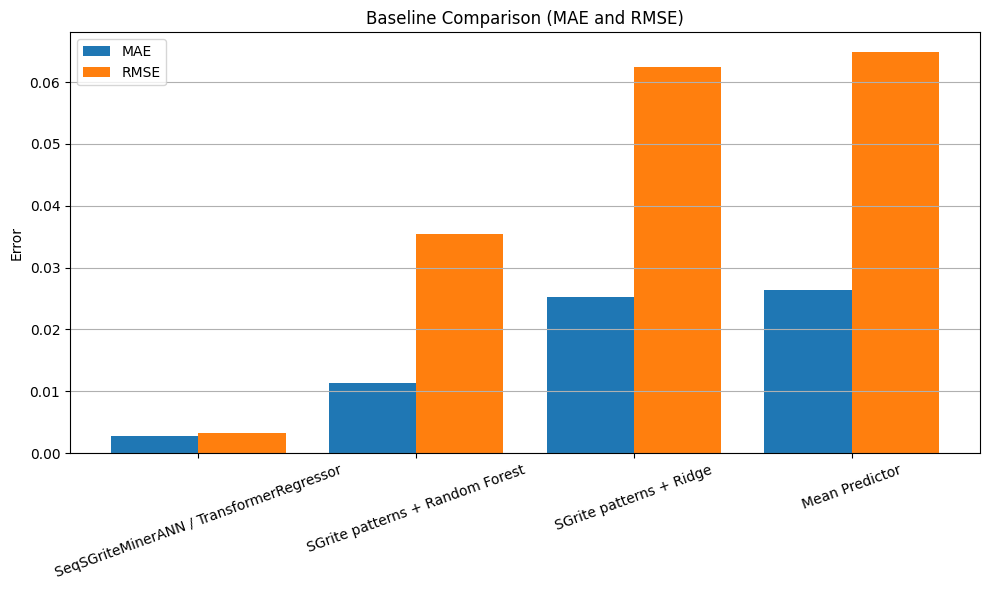

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel
import os

os.makedirs("baseline_outputs", exist_ok=True)

# -------------------------------
# 1. BAR CHART PUBLICATION
# -------------------------------

methods = comparison_df["Method"]
mae = comparison_df["MAE"]
rmse = comparison_df["RMSE"]

x = np.arange(len(methods))

plt.figure(figsize=(10,6))

plt.bar(x - 0.2, mae, width=0.4, label="MAE")
plt.bar(x + 0.2, rmse, width=0.4, label="RMSE")

plt.xticks(x, methods, rotation=20)
plt.ylabel("Error")
plt.title("Baseline Comparison (MAE and RMSE)")
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.savefig("baseline_outputs/baseline_bar_chart.png", dpi=300)
plt.show()


# -------------------------------
# 2. STATISTICAL TEST (T-TEST)
# -------------------------------

# On suppose que tu as gardé les erreurs par échantillon
# sinon ajouter lors de l'évaluation

baseline_errors = {}

# Exemple: stocker erreurs
# baseline_errors["RandomForest"] = abs(y_true - rf_pred).mean(axis=1)

# IMPORTANT : utiliser ton vrai y_true / preds
if "y_true" in globals() and "y_pred" in globals():

    full_errors = np.mean(np.abs(y_true - y_pred), axis=1)

    for name in ["SGrite + Random Forest", "SGrite + Ridge"]:
        if name in comparison_df["Method"].values:

            # ici il faut recalculer les prédictions baseline si besoin
            print(f"⚠️ Add stored predictions for {name} if not already saved")

else:
    print("⚠️ y_true / y_pred not available for t-test")